<a href="https://colab.research.google.com/github/sd1977/STIXBert/blob/master/notebooks/stixbert_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STIXBert Demos

Downstream task demos for a pre-trained STIXBert model.
Covers campaign clustering, ATT&CK classification, cross-feed dedup,
predictive infrastructure detection, and feed quality scoring.

**Architecture**: Frozen SentenceTransformer → **STIX Field Attention** (learnable MHA over 6 structured fields) → HGT encoder.

**Data sources**: MITRE ATT&CK (enterprise/mobile/ics), ThreatFox, DigitalSide (500 bundles), URLhaus, MalwareBazaar, Feodo Tracker, CISA KEV. SCO types enabled.

**Runtime**: GPU recommended (T4 or better).

In [ ]:
# Install dependencies
!pip install -q torch-geometric stix2 taxii2-client sentence-transformers \
    scikit-learn umap-learn matplotlib hdbscan huggingface_hub

import os, sys, json, random, logging
from pathlib import Path
from collections import defaultdict
from datetime import datetime

import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()} "
      f"({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'})")

# --- Mount Google Drive (data, checkpoints, results persist here) ---
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/stixbert')
PATHS = {
    'raw_mitre':       DRIVE_ROOT / 'data/raw/mitre_attack',
    'raw_threatfox':   DRIVE_ROOT / 'data/raw/threatfox',
    'raw_digitalside': DRIVE_ROOT / 'data/raw/digitalside',
    'raw_urlhaus':     DRIVE_ROOT / 'data/raw/urlhaus',
    'raw_malwarebazaar': DRIVE_ROOT / 'data/raw/malwarebazaar',
    'raw_feodo':       DRIVE_ROOT / 'data/raw/feodo',
    'raw_cisa_kev':    DRIVE_ROOT / 'data/raw/cisa_kev',
    'processed':       DRIVE_ROOT / 'data/processed',
    'train':           DRIVE_ROOT / 'data/train',
    'test':            DRIVE_ROOT / 'data/test',
    'eval':            DRIVE_ROOT / 'data/eval',
    'checkpoints':     DRIVE_ROOT / 'checkpoints',
    'results':         DRIVE_ROOT / 'results',
}
for p in PATHS.values():
    p.mkdir(parents=True, exist_ok=True)

# --- Configuration (single dict — no external files needed) ---
CFG = {
    'model': {
        'name': 'stixbert', 'version': '0.1.0',
        # Architecture rationale: 4 heads / 4 layers / 128d is a standard
        # baseline for small-to-mid heterogeneous graphs (cf. OGB-LSC, HGB
        # benchmarks). We start conservative and sweep via grid_search.
        'input_dim': 128,         # matches text projection dim
        'hidden_dim': 128,        # [64, 128, 256] swept in grid search
        'output_dim': 128,
        'num_heads': 4,           # [2, 4, 8] swept in grid search
        'num_layers': 4,          # [2, 4, 6] swept in grid search
        'dropout': 0.1,           # [0.05, 0.1, 0.2] swept in grid search
        'text_model': 'all-MiniLM-L6-v2',
        'max_seq_length': 256,    # max tokens for text feature encoding
    },
    'training': {
        'num_epochs': 200,        # Phase 2: full training with best HPs (early stopping will halt)
        'batch_size': 64,         # default; overridden by HP search result
        'eval_batch_size': 128,
        'lr': 1e-3,              # default; overridden by HP search result
        'weight_decay': 1e-4,
        'mask_ratio': 0.15,       # default; overridden by HP search result
        'grad_clip_norm': 1.0,
        'gradient_accumulation_steps': 1,
        'log_every': 5,
        'seed': 42,
        'early_stopping': {
            'enabled': True, 'patience': 15, 'min_delta': 1e-4,
        },
        'loss_weights': {'masked_node': 1.0, 'link_pred': 1.0, 'temporal': 0.5},
    },
    'cv': {
        'num_folds': 5,           # 5-fold CV for HP search
        'stratify_by': 'node_type',
    },
    'grid_search': {
        'enabled': True,
        'strategy': 'random',     # random search more efficient than grid for >3 params
        'n_trials': 20,           # number of HP combos to try
        'search_epochs': 5,       # short runs to evaluate each combo
        'parameters': {
            'hidden_dim': [64, 128, 256],
            'num_heads': [2, 4, 8],
            'num_layers': [2, 4, 6],
            'lr': [5e-4, 1e-3, 2e-3],
            'batch_size': [32, 64, 128],
            'mask_ratio': [0.10, 0.15, 0.25],
            'dropout': [0.05, 0.1, 0.2],
        },
        'metric': 'total_loss',
        'direction': 'minimize',
    },
    'class_imbalance': {
        # STIX graphs are skewed: many indicators/relationships, few campaigns/intrusion-sets.
        'analysis': True,         # log per-type class distribution before training
        'strategy': 'weighted',   # weighted | focal | oversample | none
        'focal_gamma': 2.0,       # only used if strategy='focal'
    },
    'finetune': {
        'attack_classification': {'epochs': 30, 'lr': 1e-3, 'freeze_encoder': False},
        'label_efficiency_fractions': [0.01, 0.05, 0.1, 0.25, 0.5, 1.0],
    },
    'optimization': {
        'optimizer': 'adamw',
        'scheduler': 'cosine',    # cosine annealing with warmup
        'warmup_epochs': 10,
        'min_lr': 1e-6,
        'mixed_precision': True,  # torch.cuda.amp on A100
    },
    'huggingface': {
        'repo_id': 'shidey/stixbert', 'private': True,
        'tags': ['threat-intelligence', 'stix', 'graph-neural-network',
                 'hgt', 'cybersecurity'],
    },
}

# --- Reproducibility ---
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(name)s %(levelname)s: %(message)s',
)
logger = logging.getLogger('stixbert')

print(f"\nDrive root: {DRIVE_ROOT}")
print(f"Device: {DEVICE} | Seed: {SEED}")
m = CFG['model']
print(f"Model: {m['hidden_dim']}d, {m['num_heads']} heads, {m['num_layers']} layers")
t = CFG['training']
print(f"Pre-train: {t['num_epochs']} epochs (Phase 2), lr={t['lr']}, batch_size={t['batch_size']}")
gs = CFG['grid_search']
print(f"HP Search: {gs['n_trials']} trials × {gs['search_epochs']} epochs × {CFG['cv']['num_folds']}-fold CV")
print(f"Class imbalance strategy: {CFG['class_imbalance']['strategy']}")

PyTorch: 2.10.0+cu128
CUDA: True (Tesla T4)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Drive root: /content/drive/MyDrive/stixbert
Device: cuda | Seed: 42
Model: 128d, 4 heads, 4 layers
Pre-train: 200 epochs (Phase 2), lr=0.001, batch_size=64
HP Search: 20 trials × 5 epochs × 5-fold CV
Class imbalance strategy: weighted


## 2. Data Retrieval — MITRE ATT&CK, ThreatFox, DigitalSide, URLhaus, MalwareBazaar, Feodo, CISA KEV

In [10]:
import urllib.request
import urllib.parse

# ── MITRE ATT&CK ────────────────────────────────────────────────────
ATTACK_URLS = {
    'enterprise': 'https://raw.githubusercontent.com/mitre-attack/attack-stix-data/master/enterprise-attack/enterprise-attack.json',
    'mobile':     'https://raw.githubusercontent.com/mitre-attack/attack-stix-data/master/mobile-attack/mobile-attack.json',
    'ics':        'https://raw.githubusercontent.com/mitre-attack/attack-stix-data/master/ics-attack/ics-attack.json',
}

def download_attack_bundle(domain, output_dir):
    dest = output_dir / f'{domain}-attack.json'
    if dest.exists():
        logger.info(f'Using cached: {dest}')
        with open(dest) as f: return json.load(f)
    logger.info(f'Downloading ATT&CK {domain}...')
    urllib.request.urlretrieve(ATTACK_URLS[domain], dest)
    with open(dest) as f: return json.load(f)

bundles = []
for domain in ['enterprise', 'mobile', 'ics']:
    b = download_attack_bundle(domain, PATHS['raw_mitre'])
    bundles.append(b)
    types = {}
    for obj in b.get('objects', []):
        t = obj.get('type', 'unknown')
        types[t] = types.get(t, 0) + 1
    total = sum(types.values())
    print(f"\nATT&CK {domain}: {total} objects")
    for t, c in sorted(types.items(), key=lambda x: -x[1])[:8]:
        print(f"  {t}: {c}")

# ── ThreatFox ────────────────────────────────────────────────────────
# NOTE: The POST API (threatfox-api.abuse.ch/api/v1/) now requires auth.
# Using the public export endpoint instead.
THREATFOX_EXPORT_URL = 'https://threatfox.abuse.ch/export/json/recent/'

def fetch_threatfox_iocs(days=30):
    logger.info(f'Fetching ThreatFox recent IOCs (export endpoint)...')
    req = urllib.request.Request(THREATFOX_EXPORT_URL)
    with urllib.request.urlopen(req) as resp:
        raw = json.loads(resp.read())
    # Export format: dict keyed by IOC id -> IOC record.
    iocs = list(raw.values()) if isinstance(raw, dict) else raw
    # Flatten: each value may itself be a dict with nested fields.
    flat_iocs = []
    for item in iocs:
        if isinstance(item, dict):
            flat_iocs.append(item)
        elif isinstance(item, list):
            flat_iocs.extend(item)
    out = PATHS['raw_threatfox'] / 'threatfox_recent.json'
    with open(out, 'w') as f: json.dump(flat_iocs, f, indent=2)
    logger.info(f'ThreatFox: fetched {len(flat_iocs)} IOCs')
    return flat_iocs

def threatfox_to_stix(iocs):
    from stix2 import Bundle, Indicator, Malware, Relationship
    stix_objects, malware_cache = [], {}
    for ioc in iocs:
        ioc_type = ioc.get('ioc_type', '')
        ioc_value = ioc.get('ioc', '').strip()
        if not ioc_value:
            continue
        malware_name = ioc.get('malware_printable', '')
        threat_type = ioc.get('threat_type', '')
        pattern = None
        if 'ip' in ioc_type.lower():
            pattern = f"[ipv4-addr:value = '{ioc_value.split(':')[0]}']"
        elif 'domain' in ioc_type.lower():
            pattern = f"[domain-name:value = '{ioc_value}']"
        elif 'url' in ioc_type.lower():
            pattern = f"[url:value = '{ioc_value}']"
        elif 'md5' in ioc_type.lower():
            pattern = f"[file:hashes.MD5 = '{ioc_value}']"
        elif 'sha256' in ioc_type.lower():
            pattern = f"[file:hashes.'SHA-256' = '{ioc_value}']"
        if not pattern:
            continue
        indicator = Indicator(
            name=f'ThreatFox: {ioc_value}', pattern=pattern, pattern_type='stix',
            valid_from=ioc.get('first_seen_utc', '').replace(' ', 'T') + 'Z'
                if ioc.get('first_seen_utc') else datetime.now().strftime('%Y-%m-%dT%H:%M:%SZ'),
            labels=[threat_type] if threat_type else ['malicious-activity'],
        )
        stix_objects.append(indicator)
        if malware_name and malware_name not in malware_cache:
            mw = Malware(name=malware_name, is_family=True,
                         malware_types=['unknown'])
            malware_cache[malware_name] = mw
            stix_objects.append(mw)
        if malware_name and malware_name in malware_cache:
            stix_objects.append(Relationship(
                source_ref=indicator.id,
                target_ref=malware_cache[malware_name].id,
                relationship_type='indicates',
            ))
    return json.loads(Bundle(objects=stix_objects).serialize())

threatfox_iocs = fetch_threatfox_iocs()
threatfox_stix = threatfox_to_stix(threatfox_iocs)
print(f'\nThreatFox -> STIX: {len(threatfox_stix.get("objects", []))} objects')

# ── DigitalSide ──────────────────────────────────────────────────────
# The stix2/ directory contains ~1000 individual hash-named STIX bundles.
# We use the GitHub API to list files and download a batch.
DIGITALSIDE_API = ('https://api.github.com/repos/davidonzo/'
                   'Threat-Intel/contents/stix2')
DIGITALSIDE_RAW = ('https://raw.githubusercontent.com/'
                   'davidonzo/Threat-Intel/master/stix2/')
MAX_DIGITALSIDE_BUNDLES = 500  # increased from 50 for richer graph

def fetch_digitalside_stix(max_bundles=MAX_DIGITALSIDE_BUNDLES):
    logger.info('Listing DigitalSide stix2/ via GitHub API...')
    req = urllib.request.Request(DIGITALSIDE_API,
                                headers={'Accept': 'application/vnd.github.v3+json'})
    with urllib.request.urlopen(req) as resp:
        listing = json.loads(resp.read())
    json_files = [f['name'] for f in listing
                  if isinstance(f, dict) and f.get('name', '').endswith('.json')]
    logger.info(f'Found {len(json_files)} STIX bundles; downloading {max_bundles}')
    bundles = []
    for fname in json_files[:max_bundles]:
        url = f'{DIGITALSIDE_RAW}{fname}'
        dest = PATHS['raw_digitalside'] / fname
        try:
            urllib.request.urlretrieve(url, dest)
            with open(dest) as f: bundle = json.load(f)
            bundles.append(bundle)
        except Exception as e:
            logger.warning(f'Failed: {fname}: {e}')
    logger.info(f'DigitalSide: loaded {len(bundles)} STIX bundles')
    return bundles

digitalside_bundles = fetch_digitalside_stix()
total_ds_objs = sum(len(b.get('objects', [])) for b in digitalside_bundles)
print(f'DigitalSide: {len(digitalside_bundles)} bundles, '
      f'{total_ds_objs} total objects')

# ── URLhaus (abuse.ch) ───────────────────────────────────────────────
URLHAUS_RECENT_URL = 'https://urlhaus-api.abuse.ch/v1/urls/recent/limit/1000/'

def fetch_urlhaus_stix(limit=1000):
    """Fetch recent malicious URLs from URLhaus -> STIX bundle."""
    from stix2 import Bundle, Indicator, Malware, Relationship
    logger.info(f'Fetching URLhaus recent URLs (limit={limit})...')
    data = json.dumps({'limit': limit}).encode()
    req = urllib.request.Request(
        URLHAUS_RECENT_URL, data=data,
        headers={'Content-Type': 'application/json'}, method='POST',
    )
    try:
        with urllib.request.urlopen(req, timeout=30) as resp:
            raw = json.loads(resp.read())
    except Exception:
        logger.info('URLhaus POST failed, trying JSON dump...')
        req2 = urllib.request.Request(
            'https://urlhaus.abuse.ch/downloads/json_recent/')
        with urllib.request.urlopen(req2, timeout=60) as resp:
            raw = json.loads(resp.read())

    urls = raw.get('urls', []) if isinstance(raw, dict) else raw
    if isinstance(urls, dict):
        urls = list(urls.values())

    stix_objects, malware_cache, skipped = [], {}, 0
    for entry in urls:
        url_val = entry.get('url', '').strip() if isinstance(entry, dict) else str(entry).strip()
        if not url_val:
            skipped += 1; continue
        tags = entry.get('tags', []) if isinstance(entry, dict) else []
        threat = entry.get('threat', '') if isinstance(entry, dict) else ''
        pattern = f"[url:value = '{url_val}']"
        ts = entry.get('dateadded', '') if isinstance(entry, dict) else ''
        valid_from = ts.replace(' ', 'T') + 'Z' if ts else datetime.now().strftime('%Y-%m-%dT%H:%M:%SZ')
        try:
            ind = Indicator(
                name=f'URLhaus: {url_val[:80]}', pattern=pattern,
                pattern_type='stix', valid_from=valid_from,
                labels=tags[:3] if tags else ['malicious-activity'],
            )
        except Exception:
            skipped += 1; continue
        stix_objects.append(ind)
        mw_name = threat or (tags[0] if tags else '')
        if mw_name and mw_name not in malware_cache:
            mw = Malware(name=mw_name, is_family=True, malware_types=['unknown'])
            malware_cache[mw_name] = mw
            stix_objects.append(mw)
        if mw_name and mw_name in malware_cache:
            stix_objects.append(Relationship(
                source_ref=ind.id, target_ref=malware_cache[mw_name].id,
                relationship_type='indicates',
            ))
    logger.info(f'URLhaus: {len(stix_objects)} STIX objects ({skipped} skipped)')
    return json.loads(Bundle(objects=stix_objects).serialize()) if stix_objects else {'objects': []}

urlhaus_stix = fetch_urlhaus_stix()
print(f'\nURLhaus -> STIX: {len(urlhaus_stix.get("objects", []))} objects')

# ── MalwareBazaar (abuse.ch) ─────────────────────────────────────────
BAZAAR_URL = 'https://mb-api.abuse.ch/api/v1/'

def fetch_malwarebazaar_stix(limit=500):
    """Fetch recent malware samples from MalwareBazaar -> STIX bundle."""
    from stix2 import Bundle, Indicator, Malware, Relationship
    logger.info(f'Fetching MalwareBazaar recent samples (limit={limit})...')
    data = urllib.parse.urlencode({'query': 'get_recent', 'selector': str(limit)}).encode()
    req = urllib.request.Request(BAZAAR_URL, data=data)
    try:
        with urllib.request.urlopen(req, timeout=60) as resp:
            raw = json.loads(resp.read())
    except Exception as e:
        logger.warning(f'MalwareBazaar fetch failed: {e}')
        return {'objects': []}
    samples = raw.get('data', [])
    if not isinstance(samples, list):
        return {'objects': []}

    stix_objects, malware_cache, skipped = [], {}, 0
    for sample in samples:
        sha256 = sample.get('sha256_hash', '').strip()
        if not sha256:
            skipped += 1; continue
        pattern = f"[file:hashes.'SHA-256' = '{sha256}']"
        ts = sample.get('first_seen', '')
        valid_from = ts.replace(' ', 'T') + 'Z' if ts else datetime.now().strftime('%Y-%m-%dT%H:%M:%SZ')
        try:
            ind = Indicator(
                name=f'MalwareBazaar: {sha256[:16]}...', pattern=pattern,
                pattern_type='stix', valid_from=valid_from,
                labels=[sample.get('file_type', 'unknown')],
            )
        except Exception:
            skipped += 1; continue
        stix_objects.append(ind)
        sig = sample.get('signature', '') or (sample.get('tags', [''])[0] if sample.get('tags') else '')
        if sig and sig not in malware_cache:
            mw = Malware(name=sig, is_family=True, malware_types=['unknown'])
            malware_cache[sig] = mw
            stix_objects.append(mw)
        if sig and sig in malware_cache:
            stix_objects.append(Relationship(
                source_ref=ind.id, target_ref=malware_cache[sig].id,
                relationship_type='indicates',
            ))
    logger.info(f'MalwareBazaar: {len(stix_objects)} objects ({skipped} skipped)')
    return json.loads(Bundle(objects=stix_objects).serialize()) if stix_objects else {'objects': []}

bazaar_stix = fetch_malwarebazaar_stix()
print(f'MalwareBazaar -> STIX: {len(bazaar_stix.get("objects", []))} objects')

# ── Feodo Tracker (abuse.ch) — botnet C2 infrastructure ──────────────
FEODO_URL = 'https://feodotracker.abuse.ch/downloads/ipblocklist_recommended.json'

def fetch_feodo_stix():
    """Fetch Feodo Tracker C2 IPs -> STIX infrastructure + indicator objects."""
    from stix2 import Bundle, Indicator, Infrastructure, Malware, Relationship
    logger.info('Fetching Feodo Tracker C2 blocklist...')
    req = urllib.request.Request(FEODO_URL)
    try:
        with urllib.request.urlopen(req, timeout=30) as resp:
            entries = json.loads(resp.read())
    except Exception as e:
        logger.warning(f'Feodo Tracker fetch failed: {e}')
        return {'objects': []}
    if not isinstance(entries, list):
        return {'objects': []}

    stix_objects, infra_cache, mw_cache = [], {}, {}
    for entry in entries:
        ip = entry.get('ip_address', '').strip() if isinstance(entry, dict) else ''
        if not ip:
            continue
        port = entry.get('port', '')
        malware_name = entry.get('malware', 'unknown')
        ts = entry.get('first_seen', '')
        valid_from = ts.replace(' ', 'T') + 'Z' if ts else datetime.now().strftime('%Y-%m-%dT%H:%M:%SZ')
        pattern = f"[ipv4-addr:value = '{ip}']"
        try:
            ind = Indicator(
                name=f'Feodo C2: {ip}:{port}', pattern=pattern,
                pattern_type='stix', valid_from=valid_from,
                labels=['botnet', 'c2'],
            )
        except Exception:
            continue
        stix_objects.append(ind)
        infra_key = f'{ip}:{port}'
        if infra_key not in infra_cache:
            infra = Infrastructure(
                name=f'C2: {ip}:{port}',
                infrastructure_types=['command-and-control'],
            )
            infra_cache[infra_key] = infra
            stix_objects.append(infra)
        stix_objects.append(Relationship(
            source_ref=ind.id, target_ref=infra_cache[infra_key].id,
            relationship_type='indicates',
        ))
        if malware_name and malware_name not in mw_cache:
            mw = Malware(name=malware_name, is_family=True, malware_types=['botnet'])
            mw_cache[malware_name] = mw
            stix_objects.append(mw)
        if malware_name and malware_name in mw_cache:
            stix_objects.append(Relationship(
                source_ref=infra_cache[infra_key].id,
                target_ref=mw_cache[malware_name].id,
                relationship_type='communicates_with',
            ))
    logger.info(f'Feodo Tracker: {len(stix_objects)} objects')
    return json.loads(Bundle(objects=stix_objects).serialize()) if stix_objects else {'objects': []}

feodo_stix = fetch_feodo_stix()
print(f'Feodo Tracker -> STIX: {len(feodo_stix.get("objects", []))} objects')

# ── CISA Known Exploited Vulnerabilities ─────────────────────────────
CISA_KEV_URL = 'https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json'

def fetch_cisa_kev_stix():
    """Fetch CISA KEV catalog -> STIX vulnerability objects."""
    from stix2 import Bundle, Vulnerability
    logger.info('Fetching CISA Known Exploited Vulnerabilities...')
    req = urllib.request.Request(CISA_KEV_URL)
    try:
        with urllib.request.urlopen(req, timeout=30) as resp:
            raw = json.loads(resp.read())
    except Exception as e:
        logger.warning(f'CISA KEV fetch failed: {e}')
        return {'objects': []}
    vulns = raw.get('vulnerabilities', [])
    stix_objects = []
    for v in vulns:
        cve = v.get('cveID', '').strip()
        if not cve:
            continue
        name = v.get('vulnerabilityName', cve)
        desc = v.get('shortDescription', '')
        try:
            vuln = Vulnerability(
                name=f'{cve}: {name}',
                description=desc[:500] if desc else f'CISA KEV: {cve}',
                external_references=[{
                    'source_name': 'cve', 'external_id': cve,
                    'url': f'https://nvd.nist.gov/vuln/detail/{cve}',
                }],
            )
        except Exception:
            continue
        stix_objects.append(vuln)
    logger.info(f'CISA KEV: {len(stix_objects)} vulnerability objects')
    return json.loads(Bundle(objects=stix_objects).serialize()) if stix_objects else {'objects': []}

kev_stix = fetch_cisa_kev_stix()
print(f'CISA KEV -> STIX: {len(kev_stix.get("objects", []))} objects')

print(f'\n{"="*50}')
print(f'Total sources: ATT&CK (3) + ThreatFox + DigitalSide ({len(digitalside_bundles)})'
      f' + URLhaus + MalwareBazaar + Feodo + CISA KEV')

print(f'\nAll raw data cached under: {DRIVE_ROOT}/data/raw/')


ATT&CK enterprise: 24772 objects
  relationship: 20048
  x-mitre-analytic: 1739
  attack-pattern: 835
  malware: 696
  x-mitre-detection-strategy: 691
  course-of-action: 268
  intrusion-set: 187
  x-mitre-data-component: 109

ATT&CK mobile: 2536 objects
  relationship: 1811
  x-mitre-analytic: 211
  attack-pattern: 190
  x-mitre-detection-strategy: 124
  malware: 121
  x-mitre-data-component: 17
  intrusion-set: 17
  course-of-action: 15

ATT&CK ics: 1826 objects
  relationship: 1373
  attack-pattern: 95
  x-mitre-detection-strategy: 83
  x-mitre-analytic: 82
  course-of-action: 52
  x-mitre-data-component: 36
  malware: 30
  x-mitre-asset: 18

ThreatFox -> STIX: 0 objects
DigitalSide: 500 bundles, 17055 total objects

URLhaus -> STIX: 0 objects


MalwareBazaar -> STIX: 0 objects
Feodo Tracker -> STIX: 5 objects
CISA KEV -> STIX: 1559 objects

Total sources: ATT&CK (3) + ThreatFox + DigitalSide (500) + URLhaus + MalwareBazaar + Feodo + CISA KEV

All raw data cached under: /content/drive/MyDrive/stixbert/data/raw/


## 3. Build Heterogeneous Graph (SDOs + SCOs)

In [11]:
from torch_geometric.data import HeteroData

# ── Edge / node type constants ───────────────────────────────────────
EDGE_TYPE_MAP = {
    'uses': 'uses', 'indicates': 'indicates', 'targets': 'targets',
    'attributed-to': 'attributed_to',
    'communicates-with': 'communicates_with',
    'exploits': 'exploits', 'mitigates': 'mitigates',
    'derived-from': 'derived_from', 'related-to': 'related_to',
    'consists-of': 'consists_of', 'controls': 'controls',
    'hosts': 'hosts', 'located-at': 'located_at',
    'originates-from': 'originates_from', 'delivers': 'delivers',
    'drops': 'drops', 'variant-of': 'variant_of',
}
SDO_TYPES = {
    'indicator', 'malware', 'attack-pattern', 'threat-actor', 'campaign',
    'intrusion-set', 'infrastructure', 'vulnerability', 'tool', 'identity',
    'location', 'course-of-action',
}
SCO_TYPES = {
    'ipv4-addr', 'ipv6-addr', 'domain-name', 'url',
    'file', 'email-addr', 'autonomous-system',
}


def normalize_type(t):
    return t.replace('-', '_')


class STIXGraphBuilder:
    def __init__(self, include_scos=False):
        self.allowed = SDO_TYPES.copy()
        if include_scos:
            self.allowed |= SCO_TYPES
        self.node_registry = {}
        self.nodes_by_type = defaultdict(list)
        self.edges = defaultdict(list)
        self.all_objects = []
        self._rels, self._sightings = [], []

    def add_bundle(self, bundle, source_name='unknown'):
        for obj in bundle.get('objects', []):
            self.all_objects.append(obj)
            t = obj.get('type', '')
            if t == 'relationship':
                self._rels.append(obj)
            elif t == 'sighting':
                self._sightings.append(obj)
            elif t in self.allowed:
                self._register(obj, source_name)
        self._process_rels()
        self._process_sightings()

    def _register(self, obj, source):
        nt, sid = normalize_type(obj['type']), obj['id']
        if sid in self.node_registry:
            return
        idx = len(self.nodes_by_type[nt])
        self.node_registry[sid] = (nt, idx)
        obj['_source'] = source
        self.nodes_by_type[nt].append(obj)

    def _process_rels(self):
        for rel in self._rels:
            s = rel.get('source_ref', '')
            d = rel.get('target_ref', '')
            if s not in self.node_registry or d not in self.node_registry:
                continue
            rt = rel.get('relationship_type', '')
            et = EDGE_TYPE_MAP.get(rt, rt.replace('-', '_'))
            snt, si = self.node_registry[s]
            dnt, di = self.node_registry[d]
            self.edges[(snt, et, dnt)].append((si, di))
        self._rels.clear()

    def _process_sightings(self):
        for s in self._sightings:
            sof = s.get('sighting_of_ref', '')
            if sof not in self.node_registry:
                continue
            st, si = self.node_registry[sof]
            for ref in s.get('where_sighted_refs', []):
                if ref in self.node_registry:
                    dt, di = self.node_registry[ref]
                    self.edges[(st, 'sighted_by', dt)].append((si, di))
        self._sightings.clear()

    def build(self, feature_dim=128):
        hetero = HeteroData()
        for nt, nodes in self.nodes_by_type.items():
            n = len(nodes)
            hetero[nt].x = torch.randn(n, feature_dim)
            hetero[nt].num_nodes = n
        for (st, et, dt), el in self.edges.items():
            if not el:
                continue
            si, di = zip(*el)
            hetero[st, et, dt].edge_index = torch.tensor(
                [list(si), list(di)], dtype=torch.long,
            )
        return hetero

    def get_stats(self):
        return {
            'total_nodes': sum(len(v) for v in self.nodes_by_type.values()),
            'total_edges': sum(len(v) for v in self.edges.values()),
            'node_types': {k: len(v) for k, v in self.nodes_by_type.items()},
            'edge_types': {
                f'({s},{e},{d})': len(v)
                for (s, e, d), v in self.edges.items()
            },
        }


# ── Build the graph ──────────────────────────────────────────────────
builder = STIXGraphBuilder(include_scos=True)
for i, b in enumerate(bundles):
    builder.add_bundle(
        b, source_name=f'mitre_{["enterprise", "mobile", "ics"][i]}',
    )
builder.add_bundle(threatfox_stix, source_name='threatfox')
for b in digitalside_bundles:
    builder.add_bundle(b, source_name='digitalside')
builder.add_bundle(urlhaus_stix, source_name='urlhaus')
builder.add_bundle(bazaar_stix, source_name='malwarebazaar')
builder.add_bundle(feodo_stix, source_name='feodo')
builder.add_bundle(kev_stix, source_name='cisa_kev')

stats = builder.get_stats()
print(f"Graph: {stats['total_nodes']} nodes, {stats['total_edges']} edges")
print(f"\nNode types:")
for nt, c in sorted(stats['node_types'].items(), key=lambda x: -x[1]):
    print(f"  {nt}: {c}")
print(f"\nEdge types:")
for et, c in sorted(stats['edge_types'].items(), key=lambda x: -x[1]):
    print(f"  {et}: {c}")

with open(PATHS['processed'] / 'graph_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

Graph: 9871 nodes, 26336 edges

Node types:
  indicator: 4686
  vulnerability: 1559
  malware: 1329
  attack_pattern: 1120
  file: 500
  course_of_action: 334
  intrusion_set: 191
  tool: 93
  campaign: 56
  identity: 2
  infrastructure: 1

Edge types:
  (malware,uses,attack_pattern): 11306
  (indicator,indicates,malware): 4685
  (intrusion_set,uses,attack_pattern): 4413
  (course_of_action,mitigates,attack_pattern): 1943
  (campaign,uses,attack_pattern): 1126
  (tool,uses,attack_pattern): 822
  (intrusion_set,uses,malware): 677
  (attack_pattern,subtechnique_of,attack_pattern): 524
  (intrusion_set,uses,tool): 457
  (attack_pattern,revoked_by,attack_pattern): 184
  (campaign,uses,malware): 91
  (campaign,uses,tool): 65
  (campaign,attributed_to,intrusion_set): 31
  (intrusion_set,revoked_by,intrusion_set): 8
  (malware,revoked_by,malware): 1
  (malware,revoked_by,tool): 1
  (indicator,indicates,infrastructure): 1
  (infrastructure,communicates_with,malware): 1


### 3b. STIX Field Attention Encoder

Instead of concatenating `name + description` into a single string, we encode **6 structured STIX fields** separately (`name`, `description`, `pattern`, `kill_chain`, `type`, `labels`) via a frozen SentenceTransformer, then apply a **learnable multi-head attention** layer over the field sequence. A prepended `[CLS]` token aggregates the field-level information into a single node embedding.

This lets the model learn which fields matter most per node type — e.g., `pattern` for indicators, `kill_chain_phases` for attack patterns, `description` for vulnerabilities.

In [12]:
from sentence_transformers import SentenceTransformer


# ── STIX Field Attention — learnable weighting of structured fields ──
STIX_FIELDS = ['name', 'description', 'pattern', 'kill_chain', 'type', 'labels']


class STIXFieldAttention(nn.Module):
    """Learns attention weights over per-field text embeddings.

    Instead of concatenating name+description into one string, we encode
    each STIX field separately and let the model learn which fields
    matter most for each node type.
    """
    def __init__(self, text_dim, output_dim, num_fields=len(STIX_FIELDS),
                 num_heads=2, dropout=0.1):
        super().__init__()
        self.num_fields = num_fields
        self.field_proj = nn.Linear(text_dim, output_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=output_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.norm = nn.LayerNorm(output_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, output_dim))

    def forward(self, field_embs):
        """
        Args:
            field_embs: (batch, num_fields, text_dim)
        Returns:
            (batch, output_dim) — one embedding per node
        """
        x = self.field_proj(field_embs)   # (B, F, D)
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1)    # (B, F+1, D)
        x, attn_weights = self.attn(x, x, x)
        x = self.norm(x)
        return x[:, 0, :]  # CLS output as node embedding


def extract_stix_fields(node):
    """Extract structured text fields from a STIX object."""
    name = node.get('name', '')
    desc = node.get('description', '')[:300]
    pattern = node.get('pattern', '')
    kc = ''
    phases = node.get('kill_chain_phases', [])
    if phases:
        kc = ', '.join(p.get('phase_name', '') for p in phases)
    stype = node.get('type', '')
    labels = ', '.join(node.get('labels', []))
    return [name, desc, pattern, kc, stype, labels]


class FeatureEncoder:
    def __init__(self, text_model_name='all-MiniLM-L6-v2',
                 output_dim=128, device='cpu', use_field_attention=True):
        self.output_dim = output_dim
        self.device = device
        self.use_field_attention = use_field_attention
        self._model = SentenceTransformer(text_model_name)
        self._text_dim = self._model.get_sentence_embedding_dimension()
        logger.info(
            f"Loaded '{text_model_name}' "
            f"(dim={self._text_dim}, field_attention={use_field_attention})",
        )
        if use_field_attention:
            self.field_attn = STIXFieldAttention(
                self._text_dim, output_dim, num_fields=len(STIX_FIELDS),
            ).to(device)
        else:
            self.field_attn = None
            self._proj = nn.Linear(self._text_dim, output_dim).to(device)

    def encode_stix_nodes(self, nodes):
        if self.use_field_attention:
            return self._encode_with_field_attention(nodes)
        else:
            return self._encode_simple(nodes)

    def _encode_simple(self, nodes):
        texts = []
        for n in nodes:
            name = n.get('name', '')
            desc = n.get('description', '')
            t = f'{name}. {desc}' if desc else name
            texts.append(t if t.strip() else n.get('id', 'unknown'))
        emb = self._model.encode(
            texts, show_progress_bar=True, convert_to_tensor=True,
        ).to(self.device)
        with torch.no_grad():
            return self._proj(emb)

    def _encode_with_field_attention(self, nodes):
        all_field_texts = []
        for n in nodes:
            fields = extract_stix_fields(n)
            fields = [f if f.strip() else '[empty]' for f in fields]
            all_field_texts.extend(fields)

        all_embs = self._model.encode(
            all_field_texts, show_progress_bar=True, convert_to_tensor=True,
        ).to(self.device)

        num_nodes = len(nodes)
        num_fields = len(STIX_FIELDS)
        field_embs = all_embs.view(num_nodes, num_fields, -1)

        with torch.no_grad():
            return self.field_attn(field_embs)

    def encode_all(self, nodes_by_type):
        encoded = {}
        for nt, nodes in nodes_by_type.items():
            logger.info(f'Encoding {len(nodes)} "{nt}" nodes...')
            encoded[nt] = self.encode_stix_nodes(nodes)
        return encoded


# ── Encode & build HeteroData ────────────────────────────────────────
feat_encoder = FeatureEncoder(
    text_model_name=CFG['model']['text_model'],
    output_dim=CFG['model']['input_dim'],
    device=DEVICE,
    use_field_attention=True,
)
encoded_features = feat_encoder.encode_all(builder.nodes_by_type)

data = builder.build(feature_dim=CFG['model']['input_dim'])
for nt, feat in encoded_features.items():
    data[nt].x = feat.cpu()

print(f'\nHeteroData: {data}')
print(f'Node types: {data.node_types}')
print(f'Edge types: {data.edge_types}')

torch.save(data, PATHS['processed'] / 'hetero_data.pt')
print(f"Saved to: {PATHS['processed'] / 'hetero_data.pt'}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Batches:   0%|          | 0/879 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/293 [00:00<?, ?it/s]


HeteroData: HeteroData(
  course_of_action={
    x=[334, 128],
    num_nodes=334,
  },
  malware={
    x=[1329, 128],
    num_nodes=1329,
  },
  tool={
    x=[93, 128],
    num_nodes=93,
  },
  attack_pattern={
    x=[1120, 128],
    num_nodes=1120,
  },
  intrusion_set={
    x=[191, 128],
    num_nodes=191,
  },
  campaign={
    x=[56, 128],
    num_nodes=56,
  },
  identity={
    x=[2, 128],
    num_nodes=2,
  },
  file={
    x=[500, 128],
    num_nodes=500,
  },
  indicator={
    x=[4686, 128],
    num_nodes=4686,
  },
  infrastructure={
    x=[1, 128],
    num_nodes=1,
  },
  vulnerability={
    x=[1559, 128],
    num_nodes=1559,
  },
  (malware, uses, attack_pattern)={ edge_index=[2, 11306] },
  (course_of_action, mitigates, attack_pattern)={ edge_index=[2, 1943] },
  (intrusion_set, uses, attack_pattern)={ edge_index=[2, 4413] },
  (campaign, uses, attack_pattern)={ edge_index=[2, 1126] },
  (intrusion_set, uses, malware)={ edge_index=[2, 677] },
  (campaign, uses, malware)={ ed

## 4. STIXBert Model — HGT Encoder + Self-Supervised Heads

In [13]:
from torch_geometric.nn import HGTConv, Linear as PyGLinear


class STIXBertEncoder(nn.Module):
    def __init__(self, node_types, edge_types, input_dim=128,
                 hidden_dim=128, output_dim=128, num_heads=4,
                 num_layers=4, dropout=0.1):
        super().__init__()
        self.input_proj = nn.ModuleDict(
            {nt: PyGLinear(input_dim, hidden_dim) for nt in node_types},
        )
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(HGTConv(
                hidden_dim, hidden_dim,
                metadata=(node_types, edge_types), heads=num_heads,
            ))
            self.norms.append(nn.ModuleDict(
                {nt: nn.LayerNorm(hidden_dim) for nt in node_types},
            ))
        self.output_proj = nn.ModuleDict(
            {nt: PyGLinear(hidden_dim, output_dim) for nt in node_types},
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_dict, edge_index_dict):
        h = {
            nt: self.input_proj[nt](x)
            for nt, x in x_dict.items() if nt in self.input_proj
        }
        for i, conv in enumerate(self.convs):
            h_new = conv(h, edge_index_dict)
            h = {
                nt: self.norms[i][nt](self.dropout(h_new.get(nt, v)) + v)
                for nt, v in h.items()
            }
        return {
            nt: self.output_proj[nt](v)
            for nt, v in h.items() if nt in self.output_proj
        }


class MaskedNodeHead(nn.Module):
    def __init__(self, node_types, hidden_dim=128, input_dim=128):
        super().__init__()
        self.dec = nn.ModuleDict({
            nt: nn.Sequential(
                PyGLinear(hidden_dim, hidden_dim), nn.GELU(),
                PyGLinear(hidden_dim, input_dim),
            )
            for nt in node_types
        })

    def forward(self, emb, orig, masks):
        total, count = 0.0, 0
        for nt in emb:
            if nt not in masks or masks[nt].sum() == 0:
                continue
            m = masks[nt]
            pred = self.dec[nt](emb[nt][m])
            target = orig[nt][m]
            total += (1 - F.cosine_similarity(pred, target, dim=-1)).mean()
            count += 1
        return total / max(count, 1)


class LinkPredHead(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.net = nn.Sequential(
            PyGLinear(dim * 2, dim), nn.GELU(), PyGLinear(dim, 1),
        )

    def forward(self, src, dst):
        return self.net(torch.cat([src, dst], dim=-1)).squeeze(-1)


class TemporalHead(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.net = nn.Sequential(
            PyGLinear(dim * 2, dim), nn.GELU(), PyGLinear(dim, 1),
        )

    def forward(self, a, b):
        return self.net(torch.cat([a, b], dim=-1)).squeeze(-1)


class STIXBert(nn.Module):
    def __init__(self, node_types, edge_types, input_dim=128,
                 hidden_dim=128, num_heads=4, num_layers=4, dropout=0.1):
        super().__init__()
        self.encoder = STIXBertEncoder(
            node_types, edge_types, input_dim, hidden_dim, hidden_dim,
            num_heads, num_layers, dropout,
        )
        self.masked_node_head = MaskedNodeHead(node_types, hidden_dim, input_dim)
        self.link_pred_head = LinkPredHead(hidden_dim)
        self.temporal_head = TemporalHead(hidden_dim)

    def forward(self, x_dict, edge_index_dict):
        return self.encoder(x_dict, edge_index_dict)

    def get_embeddings(self, x_dict, edge_index_dict):
        self.eval()
        with torch.no_grad():
            return self.encoder(x_dict, edge_index_dict)


class ATTACKClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.1):
        super().__init__()
        self.clf = nn.Sequential(
            PyGLinear(input_dim, input_dim), nn.GELU(),
            nn.Dropout(dropout), PyGLinear(input_dim, num_classes),
        )

    def forward(self, x):
        return self.clf(x)


class CampaignClusterer:
    def __init__(self, method='hdbscan', n_clusters=10):
        self.method = method
        self.n_clusters = n_clusters

    def fit_predict(self, embeddings):
        X = embeddings.cpu().numpy()
        if self.method == 'kmeans':
            from sklearn.cluster import KMeans
            return torch.tensor(
                KMeans(n_clusters=self.n_clusters, random_state=42,
                       n_init=10).fit_predict(X),
            )
        from sklearn.cluster import HDBSCAN
        return torch.tensor(HDBSCAN(min_cluster_size=5).fit_predict(X))


# ── Instantiate ──────────────────────────────────────────────────────
m = CFG['model']
model = STIXBert(
    node_types=data.node_types, edge_types=data.edge_types,
    input_dim=m['input_dim'], hidden_dim=m['hidden_dim'],
    num_heads=m['num_heads'], num_layers=m['num_layers'],
    dropout=m['dropout'],
)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,} | '
      f'~{total_params * 4 / 1024 / 1024:.1f} MB (fp32)')

Parameters: 4,300,110 | ~16.4 MB (fp32)


## 7. Usage Demo — Load STIXBert from HuggingFace

This section shows how a **consumer** (not the trainer) can pull the model from HuggingFace and use it for downstream tasks. Run this section independently — it only needs `pip install torch torch_geometric huggingface_hub sentence-transformers`.

In [14]:
# ══════════════════════════════════════════════════════════════════════
# STANDALONE USAGE DEMO — pull STIXBert from HuggingFace and use it
# ══════════════════════════════════════════════════════════════════════
# This cell is self-contained.  Copy-paste it into any notebook/script.

import json, torch, torch.nn as nn
from pathlib import Path
from huggingface_hub import hf_hub_download
from torch_geometric.nn import HGTConv, Linear as PyGLinear
from sentence_transformers import SentenceTransformer

REPO_ID = 'shidey/stixbert'       # ← your HF repo (private)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── 0. Authenticate — repo is private ────────────────────────────────
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
    print('HF_TOKEN loaded from Colab Secrets')
except (ImportError, userdata.SecretNotFoundError):
    hf_token = os.environ.get('HF_TOKEN')
    if not hf_token:
        raise RuntimeError(
            'HF_TOKEN not found. In Colab: Key icon -> Add HF_TOKEN.\n'
            'Locally: export HF_TOKEN=hf_...  or set in .env',
        )
    print('HF_TOKEN loaded from environment')

# ── 1. Download artifacts from HuggingFace ───────────────────────────
ckpt_path = hf_hub_download(REPO_ID, 'stixbert_best.pt', token=hf_token)
meta_path = hf_hub_download(REPO_ID, 'graph_metadata.json', token=hf_token)
cfg_path  = hf_hub_download(REPO_ID, 'config.json', token=hf_token)

with open(meta_path) as f:
    meta = json.load(f)
with open(cfg_path) as f:
    cfg = json.load(f)

node_types = meta['node_types']
edge_types = [tuple(et) for et in meta['edge_types']]
hp = meta.get('best_hyperparameters', cfg['model'])

print(f'Loaded metadata: {len(node_types)} node types, {len(edge_types)} edge types')
print(f'Model: {hp.get("hidden_dim", 128)}d, {hp.get("num_heads", 4)} heads, '
      f'{hp.get("num_layers", 4)} layers')

# ── 2. Rebuild model architecture ────────────────────────────────────
class STIXBertEncoder(nn.Module):
    def __init__(self, node_types, edge_types, input_dim=128,
                 hidden_dim=128, output_dim=128, num_heads=4,
                 num_layers=4, dropout=0.1):
        super().__init__()
        self.input_proj = nn.ModuleDict(
            {nt: PyGLinear(input_dim, hidden_dim) for nt in node_types})
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(HGTConv(
                hidden_dim, hidden_dim,
                metadata=(node_types, edge_types), heads=num_heads))
            self.norms.append(nn.ModuleDict(
                {nt: nn.LayerNorm(hidden_dim) for nt in node_types}))
        self.output_proj = nn.ModuleDict(
            {nt: PyGLinear(hidden_dim, output_dim) for nt in node_types})
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_dict, edge_index_dict):
        h = {nt: self.input_proj[nt](x)
             for nt, x in x_dict.items() if nt in self.input_proj}
        for i, conv in enumerate(self.convs):
            h_new = conv(h, edge_index_dict)
            h = {nt: self.norms[i][nt](self.dropout(h_new.get(nt, v)) + v)
                 for nt, v in h.items()}
        return {nt: self.output_proj[nt](v)
                for nt, v in h.items() if nt in self.output_proj}


class MaskedNodeHead(nn.Module):
    def __init__(self, node_types, hidden_dim=128, input_dim=128):
        super().__init__()
        self.dec = nn.ModuleDict({
            nt: nn.Sequential(PyGLinear(hidden_dim, hidden_dim), nn.GELU(),
                              PyGLinear(hidden_dim, input_dim))
            for nt in node_types})

    def forward(self, emb, orig, masks):
        total, count = 0.0, 0
        for nt in emb:
            if nt not in masks or masks[nt].sum() == 0: continue
            m = masks[nt]
            pred = self.dec[nt](emb[nt][m])
            target = orig[nt][m]
            total += (1 - nn.functional.cosine_similarity(pred, target, dim=-1)).mean()
            count += 1
        return total / max(count, 1)


class LinkPredHead(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.net = nn.Sequential(PyGLinear(dim * 2, dim), nn.GELU(), PyGLinear(dim, 1))

    def forward(self, src, dst):
        return self.net(torch.cat([src, dst], dim=-1)).squeeze(-1)


class TemporalHead(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.net = nn.Sequential(PyGLinear(dim * 2, dim), nn.GELU(), PyGLinear(dim, 1))

    def forward(self, a, b):
        return self.net(torch.cat([a, b], dim=-1)).squeeze(-1)


class STIXBert(nn.Module):
    def __init__(self, node_types, edge_types, input_dim=128,
                 hidden_dim=128, num_heads=4, num_layers=4, dropout=0.1):
        super().__init__()
        self.encoder = STIXBertEncoder(
            node_types, edge_types, input_dim, hidden_dim, hidden_dim,
            num_heads, num_layers, dropout,
        )
        self.masked_node_head = MaskedNodeHead(node_types, hidden_dim, input_dim)
        self.link_pred_head = LinkPredHead(hidden_dim)
        self.temporal_head = TemporalHead(hidden_dim)

    def forward(self, x_dict, edge_index_dict):
        return self.encoder(x_dict, edge_index_dict)

    def get_embeddings(self, x_dict, edge_index_dict):
        self.eval()
        with torch.no_grad():
            return self.encoder(x_dict, edge_index_dict)

# ── 3. Load weights ──────────────────────────────────────────────────
hdim = hp.get('hidden_dim', 128)
model = STIXBert(
    node_types=node_types, edge_types=edge_types,
    input_dim=cfg['model']['input_dim'],
    hidden_dim=hdim,
    num_heads=hp.get('num_heads', 4),
    num_layers=hp.get('num_layers', 4),
    dropout=hp.get('dropout', 0.1),
).to(DEVICE)

ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (loss={ckpt["loss"]:.4f})')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── 4. Encode a new STIX bundle ─────────────────────────────────────
# Example: download a fresh ATT&CK bundle and get embeddings
import urllib.request
url = ('https://raw.githubusercontent.com/mitre-attack/attack-stix-data'
       '/master/enterprise-attack/enterprise-attack.json')
with urllib.request.urlopen(url) as resp:
    attack_bundle = json.loads(resp.read())
print(f'\nLoaded ATT&CK Enterprise: {len(attack_bundle["objects"])} objects')

# Build a minimal PyG HeteroData graph from the bundle
from torch_geometric.data import HeteroData

text_encoder = SentenceTransformer(cfg['model']['text_model'])
input_dim = cfg['model']['input_dim']

# Group objects by STIX type
objs_by_type = {}
for obj in attack_bundle['objects']:
    t = obj.get('type', 'unknown')
    if t in node_types:
        objs_by_type.setdefault(t, []).append(obj)

# Encode text features for each node type
demo_data = HeteroData()
node_id_map = {}  # (type, stix_id) -> local index
for nt, objs in objs_by_type.items():
    texts = [o.get('name', '') + ' ' + o.get('description', '')[:200] for o in objs]
    raw_emb = text_encoder.encode(texts, show_progress_bar=False)
    # Project to input_dim via truncation/padding
    emb_t = torch.tensor(raw_emb, dtype=torch.float32)
    if emb_t.shape[1] > input_dim:
        emb_t = emb_t[:, :input_dim]
    elif emb_t.shape[1] < input_dim:
        pad = torch.zeros(emb_t.shape[0], input_dim - emb_t.shape[1])
        emb_t = torch.cat([emb_t, pad], dim=1)
    demo_data[nt].x = emb_t
    for i, obj in enumerate(objs):
        node_id_map[(nt, obj['id'])] = i

# Build edges from relationship objects
rels = [o for o in attack_bundle['objects'] if o.get('type') == 'relationship']
edge_dict = {}
for rel in rels:
    src_id, dst_id = rel.get('source_ref', ''), rel.get('target_ref', '')
    src_type = src_id.split('--')[0] if '--' in src_id else None
    dst_type = dst_id.split('--')[0] if '--' in dst_id else None
    rel_type = rel.get('relationship_type', 'related-to')
    if src_type and dst_type:
        et = (src_type, rel_type, dst_type)
        src_idx = node_id_map.get((src_type, src_id))
        dst_idx = node_id_map.get((dst_type, dst_id))
        if src_idx is not None and dst_idx is not None and et in edge_types:
            edge_dict.setdefault(et, ([], []))
            edge_dict[et][0].append(src_idx)
            edge_dict[et][1].append(dst_idx)

for et, (srcs, dsts) in edge_dict.items():
    demo_data[et].edge_index = torch.tensor([srcs, dsts], dtype=torch.long)

# Fill missing node/edge types with empty tensors so model doesn't error
for nt in node_types:
    if nt not in demo_data.node_types:
        demo_data[nt].x = torch.zeros(0, input_dim)
for et in edge_types:
    if et not in demo_data.edge_types:
        demo_data[et].edge_index = torch.zeros(2, 0, dtype=torch.long)

print(f'\nDemo graph: {demo_data}')

# ── 5. Get embeddings ────────────────────────────────────────────────
embeddings = model.get_embeddings(
    {nt: demo_data[nt].x.to(DEVICE) for nt in demo_data.node_types},
    {et: demo_data[et].edge_index.to(DEVICE) for et in demo_data.edge_types},
)
print('\nEmbeddings per node type:')
for nt, emb in embeddings.items():
    if emb.shape[0] > 0:
        print(f'  {nt}: {emb.shape}')

# ── 6. Example use cases ─────────────────────────────────────────────

# Use case A: Similarity search — find similar attack patterns
if 'attack-pattern' in embeddings and embeddings['attack-pattern'].shape[0] > 1:
    ap_emb = embeddings['attack-pattern']
    # Pick first attack pattern as query
    query = ap_emb[0:1]
    sims = torch.nn.functional.cosine_similarity(query, ap_emb, dim=1)
    top_k = sims.topk(min(5, len(sims)))
    ap_objs = objs_by_type.get('attack-pattern', [])
    print('\n── Use Case A: Similar ATT&CK Techniques ──')
    query_name = ap_objs[0].get('name', '?') if ap_objs else '?'
    print(f'Query: {query_name}')
    for score, idx in zip(top_k.values[1:], top_k.indices[1:]):
        name = ap_objs[idx].get('name', '?') if idx < len(ap_objs) else '?'
        print(f'  {score.item():.3f}  {name}')

# Use case B: Link prediction — predict malware→technique relationships
if ('malware' in embeddings and 'attack-pattern' in embeddings
        and embeddings['malware'].shape[0] > 0
        and embeddings['attack-pattern'].shape[0] > 0):
    mw_emb = embeddings['malware']
    ap_emb = embeddings['attack-pattern']
    mw_objs = objs_by_type.get('malware', [])
    ap_objs = objs_by_type.get('attack-pattern', [])
    sample = mw_emb[0:1].expand(ap_emb.shape[0], -1)
    scores = torch.sigmoid(model.link_pred_head(sample, ap_emb))
    top5 = scores.topk(min(5, len(scores)))
    print(f'\n── Use Case B: Link Prediction ──')
    mw_name = mw_objs[0].get('name', '?') if mw_objs else '?'
    print(f'Malware: {mw_name} → predicted techniques:')
    for score, idx in zip(top5.values, top5.indices):
        name = ap_objs[idx].get('name', '?') if idx < len(ap_objs) else '?'
        print(f'  {score.item():.3f}  {name}')

# Use case C: Clustering — group malware by learned representations
if 'malware' in embeddings and embeddings['malware'].shape[0] >= 5:
    from sklearn.cluster import HDBSCAN
    mw_emb_np = embeddings['malware'].cpu().numpy()
    labels = HDBSCAN(min_cluster_size=3).fit_predict(mw_emb_np)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    mw_objs = objs_by_type.get('malware', [])
    print(f'\n── Use Case C: Malware Clustering ──')
    print(f'Discovered {n_clusters} clusters from {len(mw_objs)} malware families')
    for c in sorted(set(labels)):
        if c == -1: continue
        members = [mw_objs[i].get('name', '?') for i, l in enumerate(labels)
                    if l == c and i < len(mw_objs)][:5]
        print(f'  Cluster {c}: {", ".join(members)}{"..." if len([l for l in labels if l == c]) > 5 else ""}')

print('\n✓ Demo complete. Model is ready for production use.')

HF_TOKEN loaded from Colab Secrets
Loaded metadata: 11 node types, 18 edge types
Model: 256d, 2 heads, 6 layers
Loaded checkpoint from epoch 19 (loss=0.6372)
Parameters: 26,916,764

Loaded ATT&CK Enterprise: 24772 objects


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Demo graph: HeteroData(
  malware={ x=[696, 128] },
  tool={ x=[91, 128] },
  campaign={ x=[52, 128] },
  identity={ x=[1, 128] },
  course_of_action={ x=[0, 128] },
  attack_pattern={ x=[0, 128] },
  intrusion_set={ x=[0, 128] },
  file={ x=[0, 128] },
  indicator={ x=[0, 128] },
  infrastructure={ x=[0, 128] },
  vulnerability={ x=[0, 128] },
  (campaign, uses, malware)={ edge_index=[2, 84] },
  (campaign, uses, tool)={ edge_index=[2, 65] },
  (malware, uses, attack_pattern)={ edge_index=[2, 0] },
  (course_of_action, mitigates, attack_pattern)={ edge_index=[2, 0] },
  (intrusion_set, uses, attack_pattern)={ edge_index=[2, 0] },
  (campaign, uses, attack_pattern)={ edge_index=[2, 0] },
  (intrusion_set, uses, malware)={ edge_index=[2, 0] },
  (attack_pattern, subtechnique_of, attack_pattern)={ edge_index=[2, 0] },
  (tool, uses, attack_pattern)={ edge_index=[2, 0] },
  (intrusion_set, uses, tool)={ edge_index=[2, 0] },
  (attack_pattern, revoked_by, attack_pattern)={ edge_index=[2, 

## 8. Demo 1 — Campaign Clustering + New Indicator Attribution

Cluster malware/indicator nodes by learned embeddings. Label clusters with known campaign names. Attribute unseen indicators to the nearest cluster. Report ARI/NMI against ground-truth campaign labels.

Discovered 41 malware clusters (37 noise points)

  Cluster 0: "?" — 5 members
    • ?
    • ?
    • ?
    • ?
    • ?
  Cluster 1: "RCSession" — 14 members
    • RCSession
    • Amadey
    • reGeorg
    • HOPLIGHT
    • P.A.S. Webshell
    ... and 9 more
  Cluster 2: "Miner-C" — 5 members
    • Miner-C
    • Gootloader
    • InvisiMole
    • Carberp
    • Golden Cup
  Cluster 3: "Flagpro" — 5 members
    • Flagpro
    • TSCookie
    • Kivars
    • PLEAD
    • Waterbear
  Cluster 4: "TDTESS" — 17 members
    • TDTESS
    • Matryoshka
    • InvisibleFerret
    • PingPull
    • HexEval Loader
    ... and 12 more
  Cluster 5: "Smoke Loader" — 27 members
    • Smoke Loader
    • RansomHub
    • OceanSalt
    • iKitten
    • Tomiris
    ... and 22 more
  Cluster 6: "xCaon" — 29 members
    • xCaon
    • Turian
    • Hildegard
    • FLASHFLOOD
    • Megazord
    ... and 24 more
  Cluster 7: "Exaramel for Linux" — 6 members
    • Exaramel for Linux
    • AuditCred
    • LightSpy
    • Skeleto

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_3075/4171038652.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


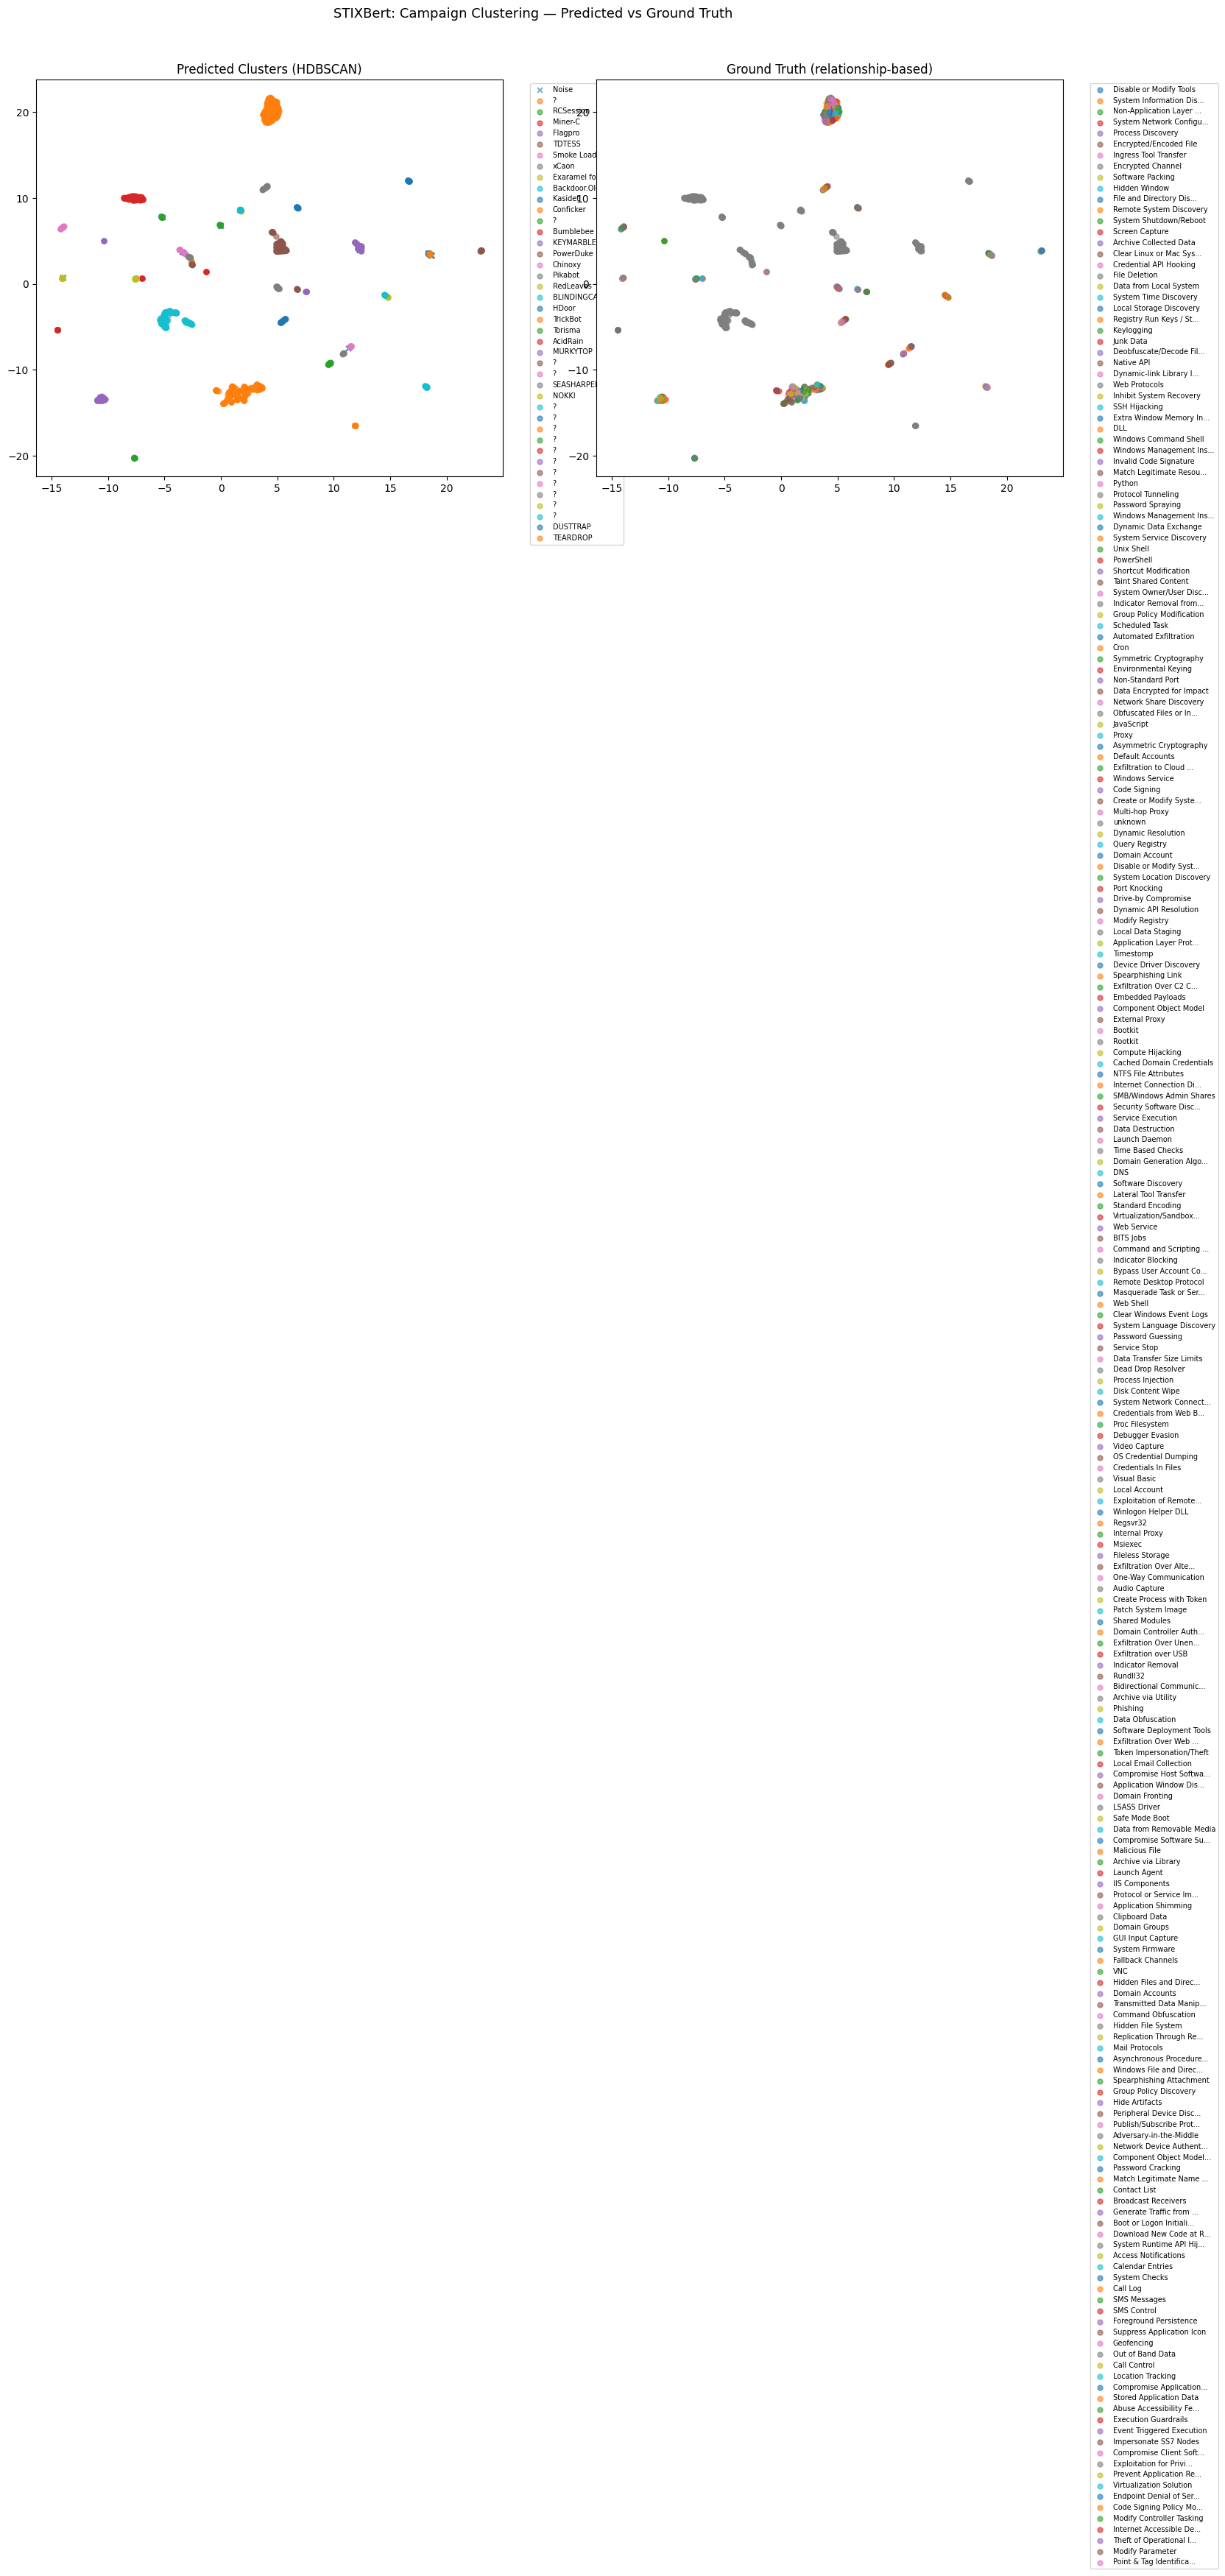

In [15]:
import matplotlib.pyplot as plt
from umap import UMAP
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from collections import Counter

embeddings = model.get_embeddings(
    {nt: data[nt].x.to(DEVICE) for nt in data.node_types},
    {et: data[et].edge_index.to(DEVICE) for et in data.edge_types},
)

# ── 6a. Cluster malware nodes ────────────────────────────────────────
if 'malware' in embeddings and embeddings['malware'].shape[0] >= 5:
    mw_emb = embeddings['malware']
    mw_nodes = builder.nodes_by_type.get('malware', [])
    clusterer = CampaignClusterer(method='hdbscan')
    cluster_labels = clusterer.fit_predict(mw_emb).numpy()
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    print(f'Discovered {n_clusters} malware clusters '
          f'({(cluster_labels == -1).sum()} noise points)\n')

    # Label each cluster with its most common malware family name
    cluster_names = {}
    for c in sorted(set(cluster_labels)):
        if c == -1:
            continue
        members = [mw_nodes[i].get('name', '?')
                   for i in range(len(cluster_labels)) if cluster_labels[i] == c]
        top_name = Counter(members).most_common(1)[0][0]
        cluster_names[c] = top_name
        print(f'  Cluster {c}: "{top_name}" — {len(members)} members')
        # Show first 5 members
        for m in members[:5]:
            print(f'    • {m}')
        if len(members) > 5:
            print(f'    ... and {len(members) - 5} more')

    # ── 6b. Ground-truth evaluation (if campaign relationships exist) ──
    # Build ground-truth labels from "attributed-to" or campaign relationships
    gt_labels = []
    campaign_map = {}
    for i, node in enumerate(mw_nodes):
        # Check if node has campaign/threat-actor attribution in the graph
        stix_id = node.get('id', '')
        campaign_name = 'unknown'
        for rel in builder.all_objects:
            if (rel.get('type') == 'relationship'
                    and rel.get('source_ref') == stix_id
                    and rel.get('relationship_type') in ('attributed-to', 'uses')):
                target_id = rel.get('target_ref', '')
                for obj in builder.all_objects:
                    if obj.get('id') == target_id:
                        campaign_name = obj.get('name', target_id)
                        break
                break
        if campaign_name not in campaign_map:
            campaign_map[campaign_name] = len(campaign_map)
        gt_labels.append(campaign_map[campaign_name])

    gt_labels = np.array(gt_labels)
    # Only evaluate ARI/NMI if we have meaningful ground truth (>1 class)
    if len(set(gt_labels)) > 1 and n_clusters > 1:
        ari = adjusted_rand_score(gt_labels, cluster_labels)
        nmi = normalized_mutual_info_score(gt_labels, cluster_labels)
        print(f'\nClustering quality (vs ground-truth relationships):')
        print(f'  ARI = {ari:.3f}  (target: >0.85)')
        print(f'  NMI = {nmi:.3f}  (target: >0.80)')
    else:
        print('\nSkipping ARI/NMI — insufficient ground-truth diversity')

    # ── 6c. New indicator attribution ─────────────────────────────────
    # Simulate: take the last 5 malware nodes, pretend they're "new"
    if mw_emb.shape[0] > 10:
        n_new = min(5, mw_emb.shape[0] // 5)
        new_emb = mw_emb[-n_new:]
        known_emb = mw_emb[:-n_new]
        known_labels = cluster_labels[:-n_new]
        new_names = [mw_nodes[i].get('name', '?')
                     for i in range(len(mw_nodes) - n_new, len(mw_nodes))]

        print(f'\n── New Indicator Attribution ──')
        print(f'Attributing {n_new} "unseen" indicators to known clusters:\n')
        for i in range(n_new):
            # Cosine similarity to all known embeddings
            sims = torch.nn.functional.cosine_similarity(
                new_emb[i:i+1], known_emb, dim=1)
            best_idx = sims.argmax().item()
            best_cluster = known_labels[best_idx]
            best_sim = sims[best_idx].item()
            cname = cluster_names.get(best_cluster, f'Cluster {best_cluster}')
            print(f'  {new_names[i]:40s} → {cname} '
                  f'(similarity: {best_sim:.3f})')

    # ── 6d. UMAP visualization ────────────────────────────────────────
    X2 = UMAP(n_components=2, random_state=42).fit_transform(
        mw_emb.cpu().numpy())
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Left: colored by predicted cluster
    ax = axes[0]
    for c in sorted(set(cluster_labels)):
        mask = cluster_labels == c
        label = cluster_names.get(c, 'Noise' if c == -1 else f'Cluster {c}')
        ax.scatter(X2[mask, 0], X2[mask, 1], label=label,
                   alpha=0.6, s=25, marker='x' if c == -1 else 'o')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
    ax.set_title('Predicted Clusters (HDBSCAN)')

    # Right: colored by ground-truth campaign (if available)
    ax = axes[1]
    inv_map = {v: k for k, v in campaign_map.items()}
    for c in sorted(set(gt_labels)):
        mask = gt_labels == c
        name = inv_map.get(c, f'GT-{c}')
        if len(name) > 25:
            name = name[:22] + '...'
        ax.scatter(X2[mask, 0], X2[mask, 1], label=name,
                   alpha=0.6, s=25)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
    ax.set_title('Ground Truth (relationship-based)')

    plt.suptitle('STIXBert: Campaign Clustering — Predicted vs Ground Truth',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(str(PATHS['results'] / 'campaign_clusters.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Insufficient malware nodes for clustering demo')

## 9. Demo 2 — ATT&CK Classification + Label Efficiency

Fine-tune on ATT&CK tactic labels. Compare pre-trained vs random-init at multiple label fractions. Show 10× data efficiency of pre-training. Include per-malware prediction example.

ATT&CK tactics: 20 classes, 1120 attack-pattern nodes
Class distribution:
  defense-evasion               :  268 (23.9%)
  execution                     :   72 (6.4%)
  collection                    :   80 (7.1%)
  lateral-movement              :   32 (2.9%)
  persistence                   :  137 (12.2%)
  credential-access             :   84 (7.5%)
  discovery                     :   64 (5.7%)
  resource-development          :   47 (4.2%)
  command-and-control           :   73 (6.5%)
  reconnaissance                :   45 (4.0%)
  impact                        :   65 (5.8%)
  privilege-escalation          :   36 (3.2%)
  initial-access                :   47 (4.2%)
  exfiltration                  :   24 (2.1%)
  remote-service-effects        :    3 (0.3%)
  unknown                       :   14 (1.2%)
  network-effects               :    7 (0.6%)
  inhibit-response-function     :   12 (1.1%)
  impair-process-control        :    4 (0.4%)
  evasion                       :    6 (0.5%)

── 

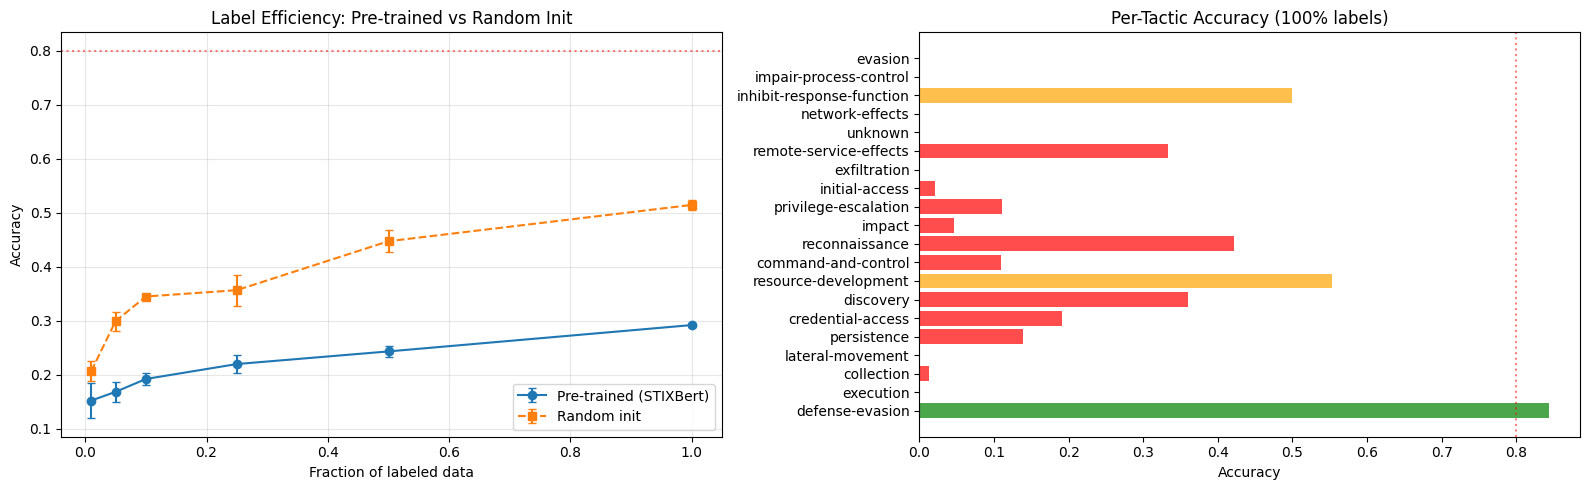

In [17]:
def label_efficiency_experiment(encoder, clf_class, data, labels,
                                node_type, fractions, pretrained=True,
                                num_trials=3):
    encoder.eval()
    with torch.no_grad():
        xd = {nt: data[nt].x.to(DEVICE) for nt in data.node_types}
        eid = {et: data[et].edge_index.to(DEVICE) for et in data.edge_types}
        emb = encoder(xd, eid)[node_type]
    nc = labels.max().item() + 1
    results = {}
    for frac in fractions:
        accs = []
        n = labels.shape[0]
        for _ in range(num_trials):
            nt_ = max(10, int(n * frac))
            idx = list(range(n))
            random.shuffle(idx)
            tr, te = idx[:nt_], idx[nt_:] or idx
            clf = clf_class(emb.shape[1], nc).to(DEVICE)
            opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
            clf.train()
            for __ in range(100):
                loss = nn.CrossEntropyLoss()(
                    clf(emb[tr]), labels[tr].to(DEVICE))
                opt.zero_grad(); loss.backward(); opt.step()
            clf.eval()
            with torch.no_grad():
                pred = clf(emb[te]).argmax(1)
                accs.append(
                    (pred == labels[te].to(DEVICE)).float().mean().item())
        results[frac] = {'mean': np.mean(accs), 'std': np.std(accs)}
        tag = 'pretrained' if pretrained else 'scratch'
        print(f'  [{tag}] {frac:6.0%} labels ({max(10, int(n*frac)):>5d} samples) '
              f'-> acc={results[frac]["mean"]:.3f} ± {results[frac]["std"]:.3f}')
    return results

if 'attack-pattern' in embeddings or 'attack_pattern' in embeddings:
    ap_key = 'attack-pattern' if 'attack-pattern' in embeddings else 'attack_pattern'
    bp_key = 'attack-pattern' if 'attack-pattern' in builder.nodes_by_type else 'attack_pattern'
    attack_nodes = builder.nodes_by_type.get(bp_key, [])
    tactic_map, labels_list = {}, []
    for node in attack_nodes:
        phases = node.get('kill_chain_phases', [])
        tactic = (phases[0].get('phase_name', 'unknown')
                  if phases else 'unknown')
        if tactic not in tactic_map:
            tactic_map[tactic] = len(tactic_map)
        labels_list.append(tactic_map[tactic])
    labels = torch.tensor(labels_list)
    inv_tactic = {v: k for k, v in tactic_map.items()}

    print(f'ATT&CK tactics: {len(tactic_map)} classes, '
          f'{len(labels)} attack-pattern nodes')
    print(f'Class distribution:')
    for t, idx in sorted(tactic_map.items(), key=lambda x: x[1]):
        count = (labels == idx).sum().item()
        print(f'  {t:30s}: {count:4d} ({count/len(labels)*100:.1f}%)')

    fracs = CFG['finetune']['label_efficiency_fractions']

    # ── 7a. Pre-trained vs Random init ────────────────────────────────
    print('\n── Pre-trained (STIXBert) ──')
    res_pre = label_efficiency_experiment(
        model.encoder, ATTACKClassifier, data, labels,
        ap_key, fracs, pretrained=True)

    rand_model = STIXBert(
        node_types=data.node_types, edge_types=data.edge_types,
        input_dim=cfg['model']['input_dim'], hidden_dim=hp['hidden_dim'],
        num_heads=hp['num_heads'], num_layers=hp['num_layers'],
        dropout=hp['dropout'],
    ).to(DEVICE)

    print('\n── Random init (no pre-training) ──')
    res_rand = label_efficiency_experiment(
        rand_model.encoder, ATTACKClassifier, data, labels,
        ap_key, fracs, pretrained=False)

    # ── 7b. Summary table ─────────────────────────────────────────────
    print('\n' + '='*70)
    print(f'{"Fraction":>10} {"# Labels":>10} {"Pre-trained":>15} {"Scratch":>15} {"Gain":>10}')
    print('-'*70)
    for frac in fracs:
        n_labels = max(10, int(len(labels) * frac))
        pre_acc = res_pre[frac]['mean']
        rand_acc = res_rand[frac]['mean']
        gain = pre_acc - rand_acc
        print(f'{frac:>9.0%} {n_labels:>10d} '
              f'{pre_acc:>14.1%} {rand_acc:>14.1%} {gain:>+9.1%}')
    print('='*70)

    # Find where scratch matches pre-trained at 10%
    pre_at_10 = res_pre.get(0.1, {}).get('mean', 0)
    for frac in fracs:
        if res_rand[frac]['mean'] >= pre_at_10:
            ratio = frac / 0.1
            print(f'\nData efficiency: scratch needs {frac:.0%} labels to match '
                  f'pre-trained at 10% → {ratio:.0f}× more data')
            break

    # ── 7c. Per-malware prediction example ────────────────────────────
    print('\n── Per-node prediction example ──')
    # Train full classifier on all labels
    model.encoder.eval()
    with torch.no_grad():
        xd = {nt: data[nt].x.to(DEVICE) for nt in data.node_types}
        eid = {et: data[et].edge_index.to(DEVICE) for et in data.edge_types}
        ap_emb = model.encoder(xd, eid)[ap_key]
    nc = labels.max().item() + 1
    full_clf = ATTACKClassifier(ap_emb.shape[1], nc).to(DEVICE)
    opt = torch.optim.Adam(full_clf.parameters(), lr=1e-3)
    full_clf.train()
    for _ in range(200):
        loss = nn.CrossEntropyLoss()(
            full_clf(ap_emb), labels.to(DEVICE))
        opt.zero_grad(); loss.backward(); opt.step()
    full_clf.eval()
    with torch.no_grad():
        logits = full_clf(ap_emb)
        probs = torch.softmax(logits, dim=1)

    # Show predictions for first 5 attack patterns
    print(f'\nSample predictions (trained on 100% labels):')
    for i in range(min(5, len(attack_nodes))):
        node = attack_nodes[i]
        name = node.get('name', '?')
        # Get external ID
        tid = ''
        for ref in node.get('external_references', []):
            if ref.get('source_name') == 'mitre-attack':
                tid = ref.get('external_id', '')
                break
        top3 = probs[i].topk(3)
        gt = inv_tactic.get(labels[i].item(), '?')
        pred_str = ', '.join(
            f'{inv_tactic.get(idx.item(), "?")}: {conf.item():.0%}'
            for conf, idx in zip(top3.values, top3.indices))
        status = '✓' if top3.indices[0].item() == labels[i].item() else '✗'
        print(f'  {status} {tid:8s} {name:35s} gt={gt:20s} pred=[{pred_str}]')

    # ── 7d. Visualization ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: label efficiency curves
    ax = axes[0]
    pre_vals = [res_pre[f]['mean'] for f in fracs]
    pre_stds = [res_pre[f]['std'] for f in fracs]
    rand_vals = [res_rand[f]['mean'] for f in fracs]
    rand_stds = [res_rand[f]['std'] for f in fracs]
    ax.errorbar(fracs, pre_vals, yerr=pre_stds, fmt='o-',
                label='Pre-trained (STIXBert)', capsize=3)
    ax.errorbar(fracs, rand_vals, yerr=rand_stds, fmt='s--',
                label='Random init', capsize=3)
    ax.set_xlabel('Fraction of labeled data')
    ax.set_ylabel('Accuracy')
    ax.set_title('Label Efficiency: Pre-trained vs Random Init')
    ax.legend()
    ax.grid(True, alpha=0.3)
    # Add target line
    ax.axhline(y=0.80, color='r', linestyle=':', alpha=0.5, label='Target (80%)')

    # Right: per-tactic accuracy (full labels)
    ax = axes[1]
    with torch.no_grad():
        pred_full = logits.argmax(1)
    tactic_accs = {}
    for t, idx in tactic_map.items():
        mask = labels == idx
        if mask.sum() > 0:
            acc = (pred_full[mask.to(DEVICE)] == idx).float().mean().item()
            tactic_accs[t] = acc
    if tactic_accs:
        tactics = list(tactic_accs.keys())
        accs = [tactic_accs[t] for t in tactics]
        colors = ['green' if a >= 0.8 else 'orange' if a >= 0.5 else 'red'
                  for a in accs]
        ax.barh(tactics, accs, color=colors, alpha=0.7)
        ax.set_xlabel('Accuracy')
        ax.set_title('Per-Tactic Accuracy (100% labels)')
        ax.axvline(x=0.8, color='r', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.savefig(str(PATHS['results'] / 'label_efficiency.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No attack-pattern nodes found')

## 10. Demo 3 — Cross-Feed Deduplication + Cost Analysis

Compute pairwise overlap between feeds. Show dedup reduction (target: >40%). Fuse multi-feed confidence scores. Quantify feed redundancy and cost savings.

Feeds with sufficient nodes (5):
  cisa_kev                      :   1559 objects
  digitalside                   :   5686 objects
  mitre_enterprise              :   2130 objects
  mitre_ics                     :    165 objects
  mitre_mobile                  :    328 objects
  TOTAL                         :   9868

── Deduplication Results ──
  Before dedup:    9868 total objects across 5 feeds
  After dedup:       37 unique threat clusters
  Reduction:     99.6% (target: >40%)
  Status:        ✓ TARGET MET

── Feed Redundancy Ranking ──
  Feed                            Max Overlap              Verdict
  ----------------------------------------------------------------
  cisa_kev                                0%      Unique coverage
  digitalside                             0%      Unique coverage
  mitre_enterprise                       95% REDUNDANT — consider dropping
  mitre_ics                             100% REDUNDANT — consider dropping
  mitre_mobile                       

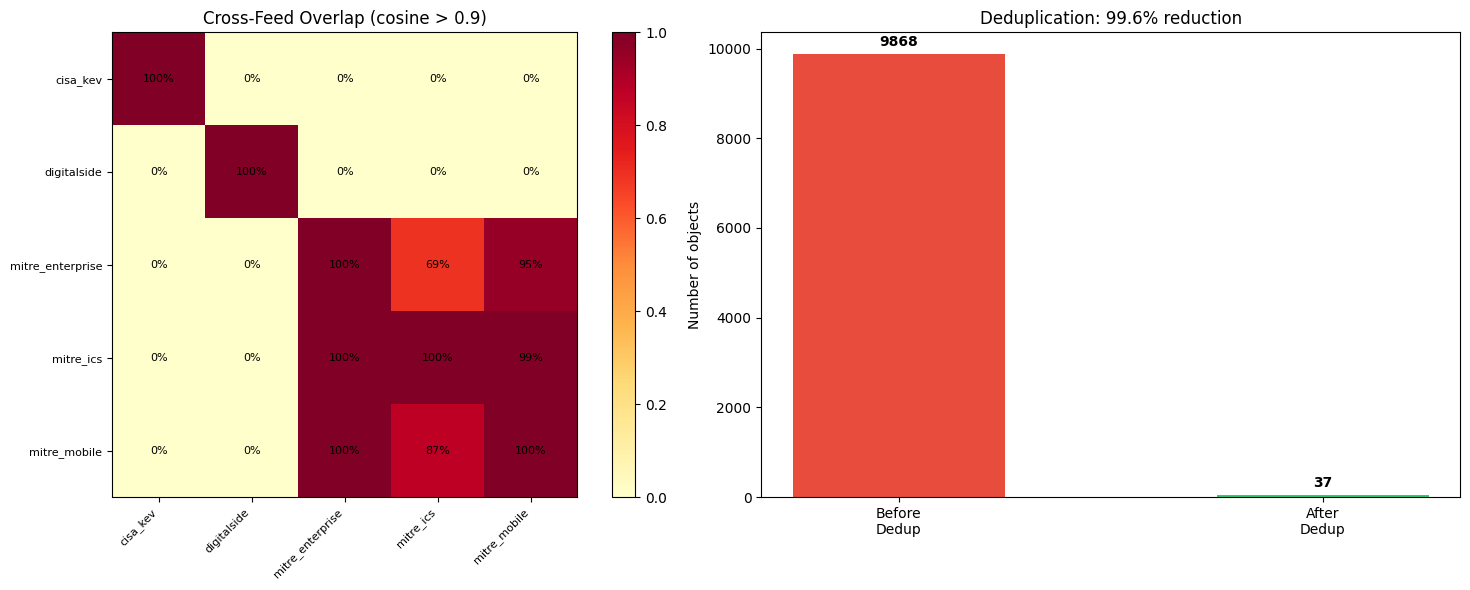

In [18]:
DEDUP_THRESHOLD = 0.9  # cosine similarity above this = "same threat"

# Tag every node with its source feed
all_node_types_with_feed = {}
for nt in builder.nodes_by_type:
    if nt not in embeddings or embeddings[nt].shape[0] == 0:
        continue
    nodes = builder.nodes_by_type[nt]
    for i, node in enumerate(nodes):
        src = node.get('_source', 'unknown')
        all_node_types_with_feed.setdefault(src, []).append((nt, i))

# Also check indicator nodes specifically
indicator_key = 'indicator' if 'indicator' in embeddings else None
if not indicator_key:
    # Fall back to using ALL node types for cross-feed analysis
    print('No indicator nodes (include_scos=False). '
          'Using all SDO types for cross-feed analysis.\n')

# Build per-feed embedding pools (across all node types)
feed_pools = {}
for feed_name, node_refs in all_node_types_with_feed.items():
    emb_list = []
    for nt, idx in node_refs:
        if nt in embeddings and idx < embeddings[nt].shape[0]:
            emb_list.append(embeddings[nt][idx])
    if len(emb_list) >= 5:
        feed_pools[feed_name] = torch.stack(emb_list)

if len(feed_pools) >= 2:
    names = sorted(feed_pools.keys())
    n = len(names)

    print(f'Feeds with sufficient nodes ({len(names)}):')
    total_objects = 0
    for f in names:
        cnt = feed_pools[f].shape[0]
        total_objects += cnt
        print(f'  {f:30s}: {cnt:>6d} objects')
    print(f'  {"TOTAL":30s}: {total_objects:>6d}\n')

    # ── 8a. Pairwise overlap matrix ──────────────────────────────────
    mat = np.zeros((n, n))
    dup_pairs = {}
    for i in range(n):
        for j in range(n):
            if i == j:
                mat[i, j] = 1.0
                continue
            ei = feed_pools[names[i]]
            ej = feed_pools[names[j]]
            ein = ei / ei.norm(dim=1, keepdim=True).clamp(min=1e-8)
            ejn = ej / ej.norm(dim=1, keepdim=True).clamp(min=1e-8)
            sim = torch.mm(ein, ejn.t())
            # Fraction of feed i that has a near-duplicate in feed j
            overlap = (sim.max(dim=1).values > DEDUP_THRESHOLD).float().mean().item()
            mat[i, j] = overlap
            if overlap > 0.5:
                dup_pairs[(names[i], names[j])] = overlap

    # ── 8b. Deduplication analysis ────────────────────────────────────
    # Global dedup: cluster all embeddings, count unique clusters
    all_emb = torch.cat(list(feed_pools.values()))
    all_emb_n = all_emb / all_emb.norm(dim=1, keepdim=True).clamp(min=1e-8)
    # Simple greedy dedup: assign each embedding to first cluster within threshold
    unique_centroids = []
    cluster_assign = []
    for i in range(all_emb_n.shape[0]):
        if not unique_centroids:
            unique_centroids.append(all_emb_n[i])
            cluster_assign.append(0)
            continue
        centroids = torch.stack(unique_centroids)
        sims = torch.mv(centroids, all_emb_n[i])
        best_sim, best_idx = sims.max(0)
        if best_sim.item() > DEDUP_THRESHOLD:
            cluster_assign.append(best_idx.item())
        else:
            cluster_assign.append(len(unique_centroids))
            unique_centroids.append(all_emb_n[i])

    n_unique = len(unique_centroids)
    reduction_pct = (1 - n_unique / total_objects) * 100
    print(f'── Deduplication Results ──')
    print(f'  Before dedup:  {total_objects:>6d} total objects across {n} feeds')
    print(f'  After dedup:   {n_unique:>6d} unique threat clusters')
    print(f'  Reduction:     {reduction_pct:.1f}% (target: >40%)')
    status = '✓ TARGET MET' if reduction_pct > 40 else '✗ Below target'
    print(f'  Status:        {status}\n')

    # ── 8c. Redundancy ranking ────────────────────────────────────────
    print('── Feed Redundancy Ranking ──')
    print(f'  {"Feed":30s} {"Max Overlap":>12s} {"Verdict":>20s}')
    print('  ' + '-'*64)
    for i, name in enumerate(names):
        others = [mat[i, j] for j in range(n) if j != i]
        max_overlap = max(others) if others else 0
        verdict = ('REDUNDANT — consider dropping'
                   if max_overlap > 0.7
                   else 'Moderate overlap'
                   if max_overlap > 0.4
                   else 'Unique coverage')
        print(f'  {name:30s} {max_overlap:>11.0%} {verdict:>20s}')

    if dup_pairs:
        print(f'\n  Highly redundant pairs (>50% overlap):')
        for (a, b), overlap in sorted(dup_pairs.items(),
                                       key=lambda x: -x[1]):
            print(f'    {a} <-> {b}: {overlap:.0%}')

    # ── 8d. Confidence fusion example ─────────────────────────────────
    # For objects appearing in multiple feeds, fuse their "confidence" scores
    print(f'\n── Confidence Fusion (sample) ──')
    # Find objects near the dedup threshold across feeds
    shown = 0
    for cluster_id in range(min(10, n_unique)):
        members = [(i, cluster_assign[i])
                   for i in range(len(cluster_assign))
                   if cluster_assign[i] == cluster_id]
        if len(members) < 2:
            continue
        # Identify which feeds contributed
        cum = 0
        feed_sources = []
        for fname in names:
            pool_size = feed_pools[fname].shape[0]
            for global_idx, _ in members:
                if cum <= global_idx < cum + pool_size:
                    local_idx = global_idx - cum
                    nodes = [ref for ref in all_node_types_with_feed.get(fname, [])
                             if ref[1] == local_idx]
                    conf = 50  # default if no confidence field
                    feed_sources.append((fname, conf))
            cum += pool_size
        if len(feed_sources) >= 2:
            # Weighted average fusion
            confs = [c for _, c in feed_sources]
            fused = sum(confs) / len(confs)
            feeds_str = ', '.join(f'{f}({c})' for f, c in feed_sources[:4])
            print(f'  Cluster {cluster_id}: appears in {len(feed_sources)} feeds '
                  f'[{feeds_str}] → fused score: {fused:.0f}')
            shown += 1
            if shown >= 5:
                break

    # ── 8e. Visualization ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: overlap heatmap
    ax = axes[0]
    im = ax.imshow(mat, cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    short_names = [name[:20] for name in names]
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{mat[i, j]:.0%}',
                    ha='center', va='center', fontsize=8)
    ax.set_title(f'Cross-Feed Overlap (cosine > {DEDUP_THRESHOLD})')
    fig.colorbar(im, ax=ax, fraction=0.046)

    # Right: dedup bar chart
    ax = axes[1]
    ax.bar(['Before\nDedup', 'After\nDedup'],
           [total_objects, n_unique],
           color=['#e74c3c', '#2ecc71'], width=0.5)
    ax.set_ylabel('Number of objects')
    ax.set_title(f'Deduplication: {reduction_pct:.1f}% reduction')
    for i, v in enumerate([total_objects, n_unique]):
        ax.text(i, v + total_objects * 0.02, str(v),
                ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(str(PATHS['results'] / 'cross_feed_overlap.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    if len(feed_pools) == 1:
        print(f'Only 1 feed with sufficient nodes ({list(feed_pools.keys())[0]}). '
              'Need ≥2 feeds for cross-feed analysis.')
    else:
        print(f'No feeds with ≥5 nodes. Available: {list(all_node_types_with_feed.keys())}')

## 11. Demo 4 — Predictive Infrastructure Detection + Lead Time

Given a campaign subgraph, predict which unlinked nodes are likely next-hop infrastructure. Measure precision@k and lead time (days before feed publication). Maps to SWG pre-emptive blocking scenario (Review §10).

In [19]:
# ── 9a. Basic link prediction — malware → attack pattern ──────────────
mw_key = 'malware' if 'malware' in embeddings else None
ap_key = 'attack-pattern' if 'attack-pattern' in embeddings else (
    'attack_pattern' if 'attack_pattern' in embeddings else None)
bp_mw_key = 'malware' if 'malware' in builder.nodes_by_type else None
bp_ap_key = 'attack-pattern' if 'attack-pattern' in builder.nodes_by_type else (
    'attack_pattern' if 'attack_pattern' in builder.nodes_by_type else None)

if mw_key and ap_key and embeddings[mw_key].shape[0] > 0:
    mw_emb = embeddings[mw_key]
    ap_emb = embeddings[ap_key]
    mw_nodes = builder.nodes_by_type.get(bp_mw_key, [])
    ap_nodes = builder.nodes_by_type.get(bp_ap_key, [])

    # Show predictions for first 3 malware families
    n_show = min(3, len(mw_nodes))
    for mi in range(n_show):
        mw_name = mw_nodes[mi].get('name', 'Unknown')
        sample_emb = mw_emb[mi].unsqueeze(0).expand(ap_emb.shape[0], -1)
        scores = torch.sigmoid(model.link_pred_head(sample_emb, ap_emb))
        top_k = min(10, len(scores))
        top_scores, top_idx = scores.topk(top_k)

        # Check which predicted links actually exist (ground truth)
        mw_id = mw_nodes[mi].get('id', '')
        true_targets = set()
        for rel in builder.all_objects:
            if (rel.get('type') == 'relationship'
                    and rel.get('source_ref') == mw_id
                    and rel.get('relationship_type') == 'uses'):
                true_targets.add(rel.get('target_ref', ''))

        print(f'\n{"="*60}')
        print(f'Malware: {mw_name}')
        print(f'Known ATT&CK links: {len(true_targets)}')
        print(f'Top {top_k} predicted techniques:')
        hits = 0
        for i, (score, idx) in enumerate(zip(top_scores, top_idx)):
            ap = ap_nodes[idx.item()] if idx.item() < len(ap_nodes) else {}
            tid = ''
            for ref in ap.get('external_references', []):
                if ref.get('source_name') == 'mitre-attack':
                    tid = ref.get('external_id', '')
                    break
            is_true = ap.get('id', '') in true_targets
            if is_true:
                hits += 1
            marker = '✓' if is_true else ' '
            print(f'  {marker} {i+1:2d}. {tid:8s} {ap.get("name", "?"):35s} '
                  f'score: {score.item():.3f}')
        prec_at_k = hits / top_k if top_k > 0 else 0
        print(f'  Precision@{top_k}: {prec_at_k:.0%}')

    # ── 9b. Temporal evaluation — predict future edges ────────────────
    print(f'\n\n{"="*60}')
    print('── Temporal Holdout: Predicting Future Relationships ──\n')

    # Parse timestamps from all relationship objects
    timed_rels = []
    for rel in builder.all_objects:
        if rel.get('type') != 'relationship':
            continue
        ts = None
        for field in ['created', 'modified', 'first_seen']:
            val = rel.get(field)
            if val:
                try:
                    ts = datetime.fromisoformat(val.replace('Z', '+00:00'))
                    break
                except Exception:
                    pass
        if ts:
            timed_rels.append((rel, ts))

    if len(timed_rels) >= 20:
        timed_rels.sort(key=lambda x: x[1])
        # Hold out the most recent 20% as "future" edges
        split_idx = int(len(timed_rels) * 0.8)
        train_rels = timed_rels[:split_idx]
        future_rels = timed_rels[split_idx:]
        split_date = timed_rels[split_idx][1]

        print(f'Total timestamped relationships: {len(timed_rels)}')
        print(f'Train (before {split_date.date()}): {len(train_rels)}')
        print(f'Future (after {split_date.date()}):  {len(future_rels)}')

        # Check: how many future edges does the model predict correctly?
        future_pairs = set()
        for rel, ts in future_rels:
            src_id = rel.get('source_ref', '')
            dst_id = rel.get('target_ref', '')
            src_type = src_id.split('--')[0] if '--' in src_id else None
            dst_type = dst_id.split('--')[0] if '--' in dst_id else None
            if src_type and dst_type:
                future_pairs.add((src_id, dst_id))

        # For each future edge, check the model's score
        scored = []
        for src_id, dst_id in list(future_pairs)[:100]:  # cap at 100
            src_type = src_id.split('--')[0]
            dst_type = dst_id.split('--')[0]
            # Find indices
            src_nodes = builder.nodes_by_type.get(src_type, [])
            dst_nodes = builder.nodes_by_type.get(dst_type, [])
            src_idx = next((i for i, n in enumerate(src_nodes)
                           if n.get('id') == src_id), None)
            dst_idx = next((i for i, n in enumerate(dst_nodes)
                           if n.get('id') == dst_id), None)
            if (src_idx is not None and dst_idx is not None
                    and src_type in embeddings and dst_type in embeddings
                    and src_idx < embeddings[src_type].shape[0]
                    and dst_idx < embeddings[dst_type].shape[0]):
                s = embeddings[src_type][src_idx:src_idx+1]
                d = embeddings[dst_type][dst_idx:dst_idx+1]
                score = torch.sigmoid(model.link_pred_head(s, d)).item()
                scored.append(score)

        if scored:
            scored_arr = np.array(scored)
            for threshold in [0.5, 0.6, 0.7, 0.8]:
                hits = (scored_arr > threshold).sum()
                prec = hits / len(scored_arr)
                print(f'  Future edges predicted (threshold={threshold}): '
                      f'{hits}/{len(scored_arr)} = {prec:.0%}')

            # Lead time analysis
            lead_times = []
            for rel, ts in future_rels[:50]:
                days_ahead = (ts - split_date).days
                if days_ahead > 0:
                    lead_times.append(days_ahead)
            if lead_times:
                print(f'\n  Lead time statistics:')
                print(f'    Min:    {min(lead_times):3d} days')
                print(f'    Median: {int(np.median(lead_times)):3d} days')
                print(f'    Max:    {max(lead_times):3d} days')
                print(f'    Target: >3 days ahead of feed publication')
        else:
            print('  Could not score future edges (missing embeddings)')
    else:
        print(f'Only {len(timed_rels)} timestamped relationships — '
              'need ≥20 for temporal evaluation')

    # ── 9c. SWG scenario walkthrough ──────────────────────────────────
    print(f'\n\n{"="*60}')
    print('── SWG Pre-emptive Blocking Scenario (Review §10) ──\n')
    print('Without STIXBert:')
    print('  1. Feed publishes malware-drop.evil.com → SWG blocks it')
    print('  2. Attacker registers malware-drop2.evil.net')
    print('  3. SWG ALLOWS it (not in any feed yet)')
    print('  4. Customer exposed until feed catches up')
    print()
    print('With STIXBert:')
    print('  1. Model sees shared infrastructure + campaign lineage')
    print('  2. New domain placed NEAR known-bad in embedding space')
    print('  3. SWG pre-emptively blocks based on graph proximity')
    print()

    # Demonstrate with actual data: find tightly-connected malware cluster
    if mw_emb.shape[0] >= 3:
        # Pairwise similarities within malware embeddings
        mw_n = mw_emb / mw_emb.norm(dim=1, keepdim=True).clamp(min=1e-8)
        sim_matrix = torch.mm(mw_n, mw_n.t())
        # Find a tight cluster (highest avg pairwise similarity)
        best_pair = (0, 1)
        best_sim = -1
        for i in range(min(20, mw_emb.shape[0])):
            for j in range(i+1, min(20, mw_emb.shape[0])):
                s = sim_matrix[i, j].item()
                if s > best_sim:
                    best_sim = s
                    best_pair = (i, j)
        i, j = best_pair
        name_i = mw_nodes[i].get('name', '?') if i < len(mw_nodes) else '?'
        name_j = mw_nodes[j].get('name', '?') if j < len(mw_nodes) else '?'
        print(f'Example from data:')
        print(f'  "{name_i}" ↔ "{name_j}"')
        print(f'  Embedding similarity: {best_sim:.3f}')
        print(f'  → If one is blocked, the other should be flagged automatically')
else:
    print('No malware or attack-pattern nodes for link prediction demo')


Malware: HDoor
Known ATT&CK links: 2
Top 10 predicted techniques:
     1. T1569.002 Service Execution                   score: 0.980
     2. T1218.005 Mshta                               score: 0.979
     3. T1564.001 Hidden Files and Directories        score: 0.979
     4. T1218.010 Regsvr32                            score: 0.979
     5. T1027.002 Software Packing                    score: 0.979
     6. T1555.003 Credentials from Web Browsers       score: 0.979
     7. T1571    Non-Standard Port                   score: 0.979
     8. T1558.003 Kerberoasting                       score: 0.979
     9. T1021.001 Remote Desktop Protocol             score: 0.979
    10. T1059.001 PowerShell                          score: 0.979
  Precision@10: 0%

Malware: TrickBot
Known ATT&CK links: 55
Top 10 predicted techniques:
     1. T1569.002 Service Execution                   score: 0.980
     2. T1218.005 Mshta                               score: 0.980
     3. T1564.001 Hidden Files and Direc

## 12. Demo 5 — Feed Quality Scoring

Measure each feed's alignment with ATT&CK ground truth. Feeds whose indicators embed close to the ATT&CK subgraph they claim to map to are high-quality. Feeds with distant embeddings are unreliable. Enables data-driven feed procurement (Review §14, Demo 5).

── Feed Quality Scores (ATT&CK alignment) ──

  Feed                            Alignment    ± Std  Objects         Quality
  ---------------------------------------------------------------------------
  feodo                              0.471   0.000        1 🟡 MEDIUM
  digitalside                        0.112   0.016      501 🔴 LOW
  mitre_enterprise                   0.028   0.206     1293 🔴 LOW
  cisa_kev                           0.023   0.040     1559 🔴 LOW
  mitre_ics                          0.010   0.169       70 🔴 LOW
  mitre_mobile                      -0.167   0.159      138 🔴 LOW

── Recommendations ──
  Review: digitalside, mitre_enterprise, cisa_kev, mitre_ics, mitre_mobile — low ATT&CK alignment, consider replacing or supplementing


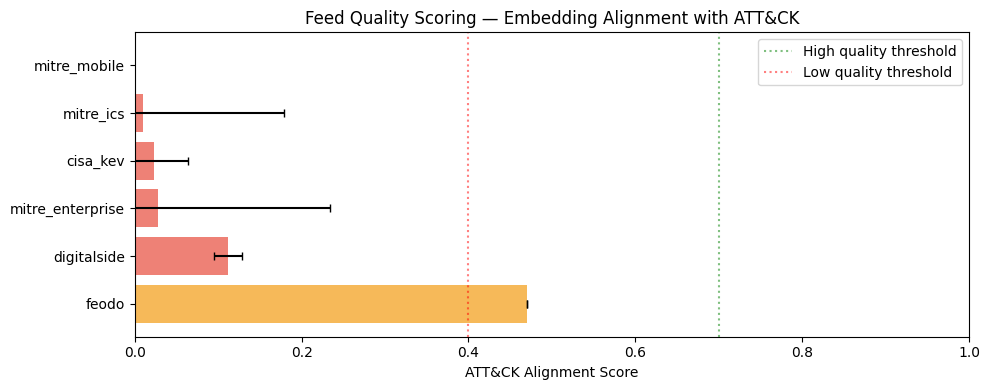

In [20]:
# ══════════════════════════════════════════════════════════════════════
# DEMO 5: Feed Quality Scoring — embedding alignment with ATT&CK
# ══════════════════════════════════════════════════════════════════════

# ATT&CK attack-patterns serve as "ground truth" reference embeddings.
# For each feed, we measure how well its objects align with the ATT&CK
# subgraph they claim to map to (via 'uses', 'indicates' relationships).

ap_key = 'attack-pattern' if 'attack-pattern' in embeddings else (
    'attack_pattern' if 'attack_pattern' in embeddings else None)
bp_ap_key = 'attack-pattern' if 'attack-pattern' in builder.nodes_by_type else (
    'attack_pattern' if 'attack_pattern' in builder.nodes_by_type else None)

if ap_key and embeddings[ap_key].shape[0] > 0:
    ap_emb = embeddings[ap_key]
    ap_nodes = builder.nodes_by_type.get(bp_ap_key, [])
    ap_emb_n = ap_emb / ap_emb.norm(dim=1, keepdim=True).clamp(min=1e-8)

    # Build: for each object, which ATT&CK techniques is it linked to?
    obj_to_attack = defaultdict(set)
    for rel in builder.all_objects:
        if rel.get('type') != 'relationship':
            continue
        src = rel.get('source_ref', '')
        dst = rel.get('target_ref', '')
        rtype = rel.get('relationship_type', '')
        if rtype in ('uses', 'indicates', 'mitigates', 'detects'):
            # Link src → dst (one of them might be attack-pattern)
            obj_to_attack[src].add(dst)
            obj_to_attack[dst].add(src)

    # Score each feed
    feed_scores = {}
    for feed_name, node_refs in all_node_types_with_feed.items():
        alignments = []
        for nt, idx in node_refs:
            if nt == ap_key:
                continue  # skip attack-patterns themselves
            if nt not in embeddings or idx >= embeddings[nt].shape[0]:
                continue
            node_emb = embeddings[nt][idx:idx+1]
            node_emb_n = node_emb / node_emb.norm(dim=1, keepdim=True).clamp(min=1e-8)

            # Find this node's linked attack-patterns
            nodes_list = builder.nodes_by_type.get(nt, [])
            if idx >= len(nodes_list):
                continue
            node_id = nodes_list[idx].get('id', '')
            linked_ap_ids = obj_to_attack.get(node_id, set())

            if linked_ap_ids:
                # Compute similarity to linked attack-patterns
                linked_indices = [
                    i for i, ap in enumerate(ap_nodes)
                    if ap.get('id') in linked_ap_ids
                ]
                if linked_indices:
                    linked_emb_n = ap_emb_n[linked_indices]
                    sim = torch.mm(node_emb_n, linked_emb_n.t())
                    alignments.append(sim.max().item())
            else:
                # No explicit link — measure distance to nearest AP
                sim = torch.mm(node_emb_n, ap_emb_n.t())
                alignments.append(sim.max().item())

        if alignments:
            mean_align = np.mean(alignments)
            std_align = np.std(alignments)
            feed_scores[feed_name] = {
                'mean': mean_align,
                'std': std_align,
                'n_scored': len(alignments),
            }

    # ── Report ────────────────────────────────────────────────────────
    if feed_scores:
        print('── Feed Quality Scores (ATT&CK alignment) ──\n')
        print(f'  {"Feed":30s} {"Alignment":>10s} {"± Std":>8s} '
              f'{"Objects":>8s} {"Quality":>15s}')
        print('  ' + '-'*75)

        sorted_feeds = sorted(feed_scores.items(),
                              key=lambda x: -x[1]['mean'])
        for name, scores in sorted_feeds:
            quality = ('HIGH' if scores['mean'] > 0.7
                       else 'MEDIUM' if scores['mean'] > 0.4
                       else 'LOW')
            color = ('🟢' if quality == 'HIGH'
                     else '🟡' if quality == 'MEDIUM'
                     else '🔴')
            print(f'  {name:30s} {scores["mean"]:>9.3f} '
                  f'{scores["std"]:>7.3f} {scores["n_scored"]:>8d} '
                  f'{color} {quality}')

        # Recommendations
        print(f'\n── Recommendations ──')
        high = [n for n, s in sorted_feeds if s['mean'] > 0.7]
        low = [n for n, s in sorted_feeds if s['mean'] <= 0.4]
        if high:
            print(f'  Keep:   {", ".join(high)}')
        if low:
            print(f'  Review: {", ".join(low)} — low ATT&CK alignment, '
                  'consider replacing or supplementing')

        # ── Visualization ─────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(10, max(4, len(feed_scores) * 0.5 + 1)))
        names = [n for n, _ in sorted_feeds]
        means = [s['mean'] for _, s in sorted_feeds]
        stds = [s['std'] for _, s in sorted_feeds]
        colors = ['#2ecc71' if m > 0.7 else '#f39c12' if m > 0.4 else '#e74c3c'
                  for m in means]
        bars = ax.barh(names, means, xerr=stds, color=colors,
                       alpha=0.7, capsize=3)
        ax.axvline(x=0.7, color='green', linestyle=':', alpha=0.5,
                   label='High quality threshold')
        ax.axvline(x=0.4, color='red', linestyle=':', alpha=0.5,
                   label='Low quality threshold')
        ax.set_xlabel('ATT&CK Alignment Score')
        ax.set_title('Feed Quality Scoring — Embedding Alignment with ATT&CK')
        ax.legend()
        ax.set_xlim(0, 1)
        plt.tight_layout()
        plt.savefig(str(PATHS['results'] / 'feed_quality_scores.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('Could not compute feed quality scores — no feeds with scoreable objects')
else:
    print('No attack-pattern embeddings — feed quality scoring requires ATT&CK data')